In [13]:
!pip install hmmlearn

In [14]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Install hmmlearn if not already installed


# For HMM
from hmmlearn import hmm

# For statistics
from scipy import stats
from scipy.stats import multivariate_normal
import statsmodels.api as sm

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")
print(f"Today's date: {datetime.now().strftime('%Y-%m-%d')}")

Libraries imported successfully!
Today's date: 2026-02-24



# STEP 1A: DATA DOWNLOAD


In [15]:


import pandas as pd
import yfinance as yf
import os
from datetime import datetime

print("="*80)
print("STEP 1A: DATA DOWNLOAD")
print("="*80)

DATA_FILE = "raw_etf_vix_data.parquet"

etf_tickers = ['TLT', 'GLD', 'SPY']
vix_ticker = '^VIX'
start_date = '2000-01-01'
end_date = datetime.now().strftime('%Y-%m-%d')

if os.path.exists(DATA_FILE):
    print(f"\nFile '{DATA_FILE}' already exists. Skipping download ✅")

else:
    print(f"\nDownloading data for {etf_tickers + [vix_ticker]} "
          f"from {start_date} to {end_date}...")

    # Download ETFs
    etf_full_data = yf.download(etf_tickers, start=start_date, end=end_date)
    etf_data_adj_close = etf_full_data['Close']

    # Download VIX
    vix_data_close = yf.download(vix_ticker, start=start_date, end=end_date)['Close']

    # Combine
    data = pd.concat([etf_data_adj_close, vix_data_close], axis=1)
    data.columns = ['TLT', 'GLD', 'SPY', 'VIX']

    data.to_parquet(DATA_FILE)

    print(f"\nData saved as '{DATA_FILE}' ✅")

print("="*80)

STEP 1A: DATA DOWNLOAD

File 'raw_etf_vix_data.parquet' already exists. Skipping download ✅


# =============================================================================
# STEP 1B: DATA PREPARATION AND EXPLORATION


In [16]:

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta # Import datetime explicitly



print("="*80)
print("STEP 1: Data Preparation and Exploration")
print("="*80)

DATA_FILE = "raw_etf_vix_data.parquet"

# Load data
data = pd.read_parquet(DATA_FILE)

print(f"\nOriginal data shape: {data.shape}")
print(f"Missing values per column:\n{data.isnull().sum()}")

# Remove missing values
data_clean = data.dropna()

print(f"\nData shape after removing missing values: {data_clean.shape}")
print(f"Date range: {data_clean.index[0].strftime('%Y-%m-%d')} "
      f"to {data_clean.index[-1].strftime('%Y-%m-%d')}")

print(f"\nFirst few rows of clean data:")
print(data_clean.head())

# 2. Compute daily returns
processed_data = data_clean.copy()

# For ETFs: log returns
for etf in ['TLT', 'GLD', 'SPY']:
    processed_data[f'{etf}_logret'] = np.log(
        processed_data[etf] / processed_data[etf].shift(1)
    )

# For VIX: simple change and returns
processed_data['VIX_change'] = processed_data['VIX'].diff()
processed_data['VIX_ret'] = processed_data['VIX'].pct_change()

# Drop first NaN row
processed_data = processed_data.dropna()

print(f"\nFinal data shape with returns: {processed_data.shape}")

print(f"\nDescriptive statistics:")
print(processed_data[
    ['TLT_logret', 'GLD_logret', 'SPY_logret', 'VIX_change', 'VIX_ret']
].describe())


# For ETFs: log returns
for etf in ['TLT', 'GLD', 'SPY']:
    processed_data[f'{etf}_logret'] = np.log(processed_data[etf] / processed_data[etf].shift(1))

# For VIX: simple change and returns
processed_data['VIX_change'] = processed_data['VIX'].diff()
processed_data['VIX_ret'] = processed_data['VIX'].pct_change()

# Drop the first row with NaN returns
processed_data = processed_data.dropna()

print(f"\nFinal data shape with returns: {processed_data.shape}")
print(f"\nDescriptive statistics:")
print(processed_data[['TLT_logret', 'GLD_logret', 'SPY_logret', 'VIX_change', 'VIX_ret']].describe())



STEP 1: Data Preparation and Exploration

Original data shape: (6574, 4)
Missing values per column:
TLT    1226
GLD       0
SPY     644
VIX       0
dtype: int64

Data shape after removing missing values: (5348, 4)
Date range: 2004-11-18 to 2026-02-23

First few rows of clean data:
                  TLT        GLD        SPY    VIX
Date                                              
2004-11-18  44.380001  80.169067  44.649818  12.98
2004-11-19  44.779999  79.277832  44.293491  13.50
2004-11-22  44.950001  79.655937  44.524372  12.97
2004-11-23  44.750000  79.777458  44.579605  12.67
2004-11-24  45.049999  79.966522  44.579605  12.72

Final data shape with returns: (5347, 9)

Descriptive statistics:
        TLT_logret   GLD_logret   SPY_logret   VIX_change      VIX_ret
count  5347.000000  5347.000000  5347.000000  5347.000000  5347.000000
mean      0.000446     0.000400     0.000131     0.001502     0.003025
std       0.011345     0.011959     0.009211     1.906272     0.079678
min      -

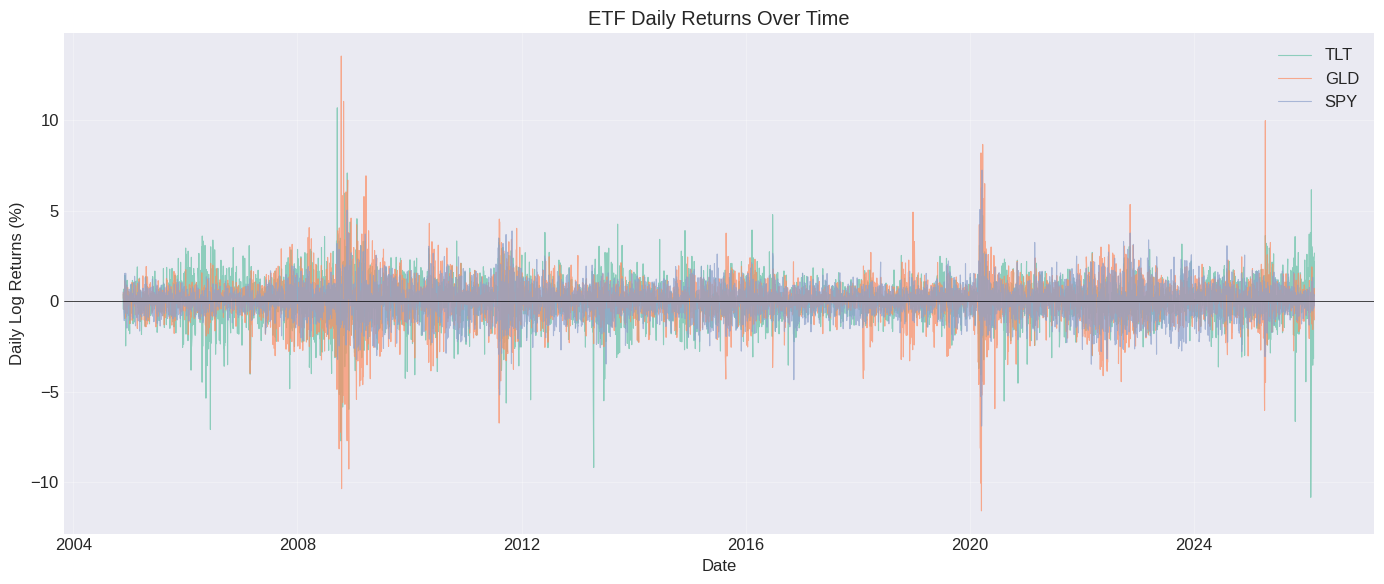

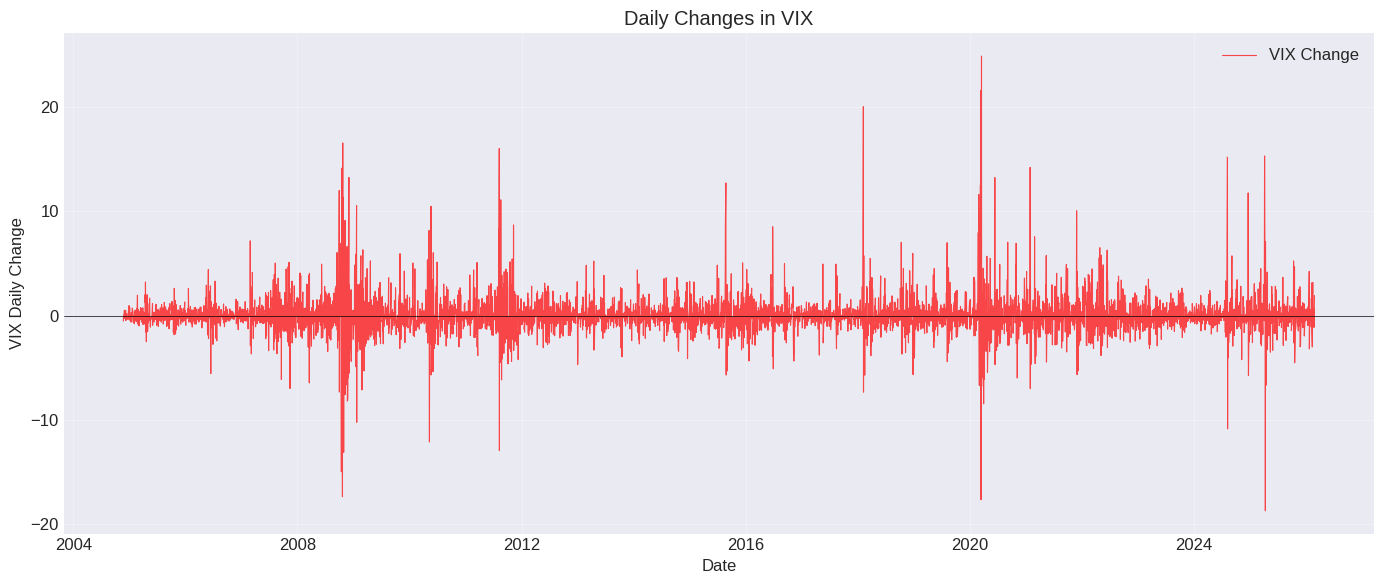

In [17]:
# 3. Visualizations

# ===============================
# Plot 1: ETF returns
# ===============================
plt.figure(figsize=(14, 6))

plt.plot(processed_data.index, processed_data['TLT_logret'] * 100, label='TLT', alpha=0.7, linewidth=0.8)
plt.plot(processed_data.index, processed_data['GLD_logret'] * 100, label='GLD', alpha=0.7, linewidth=0.8)
plt.plot(processed_data.index, processed_data['SPY_logret'] * 100, label='SPY', alpha=0.7, linewidth=0.8)

plt.xlabel('Date')
plt.ylabel('Daily Log Returns (%)')
plt.title('ETF Daily Returns Over Time')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('step1_etf_returns.png', dpi=150, bbox_inches='tight')
plt.show()


# ===============================
# Plot 2: VIX change
# ===============================
plt.figure(figsize=(14, 6))

plt.plot(processed_data.index, processed_data['VIX_change'],
         label='VIX Change', color='red', alpha=0.7, linewidth=0.8)

plt.xlabel('Date')
plt.ylabel('VIX Daily Change')
plt.title('Daily Changes in VIX')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('step1_vix_change.png', dpi=150, bbox_inches='tight')
plt.show()



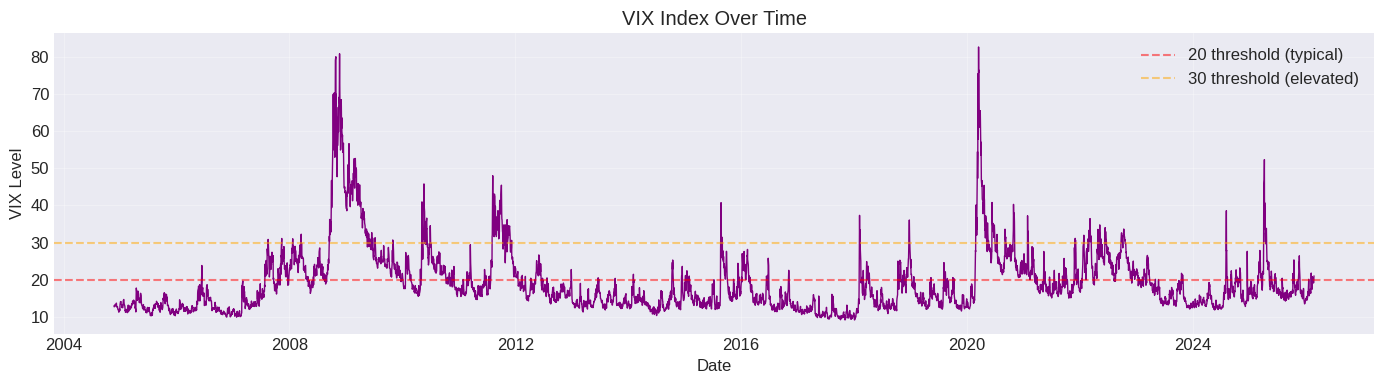


✓ Step 1 completed: Data downloaded, cleaned, and visualized


In [18]:
# Additional plot: VIX level over time
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(processed_data.index, processed_data['VIX'], color='purple', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('VIX Level')
ax.set_title('VIX Index Over Time')
ax.grid(True, alpha=0.3)
ax.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='20 threshold (typical)')
ax.axhline(y=30, color='orange', linestyle='--', alpha=0.5, label='30 threshold (elevated)')
ax.legend()
plt.tight_layout()
plt.savefig('step1_vix_level.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Step 1 completed: Data downloaded, cleaned, and visualized")


# STEP 2: Modeling VIX Regimes


In [41]:


print("\n" + "="*80)
print("STEP 2: Modeling VIX Regimes")
print("="*80)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# Data Preparation (using processed_data from Step 1)
# -----------------------------------------------------------------------------

# Assuming processed_data is available from Step 1
# If running standalone, uncomment the following:
# processed_data = pd.read_csv('step1_processed_data.csv', index_col=0, parse_dates=True)

vix_data = processed_data[['VIX', 'VIX_change']].copy()
print(f"\nData shape: {vix_data.shape}")
print(f"Date range: {vix_data.index[0]} to {vix_data.index[-1]}")

print(f"\nVIX change statistics (ΔVIX):")
print(f"  Mean: {vix_data['VIX_change'].mean():.4f}")
print(f"  Std: {vix_data['VIX_change'].std():.4f}")
print(f"  Min: {vix_data['VIX_change'].min():.4f}")
print(f"  Max: {vix_data['VIX_change'].max():.4f}")


STEP 2: Modeling VIX Regimes

Data shape: (5346, 2)
Date range: 2004-11-22 00:00:00 to 2026-02-23 00:00:00

VIX change statistics (ΔVIX):
  Mean: 0.0014
  Std: 1.9064
  Min: -18.7100
  Max: 24.8600


In [42]:


# =============================================================================
# OPTION 1: Discrete Markov Chain Approach
# =============================================================================

print("\n" + "="*80)
print("OPTION 1: Discrete Markov Chain")
print("="*80)


def create_discrete_states(data, n_states=2, variable='VIX_change'):
    """
    Discretize continuous variable into states using quantiles

    Parameters:
    - data: DataFrame with the variable
    - n_states: 2 or 3 states
    - variable: column name to discretize

    Returns:
    - states: Series with state labels (0,1,...)
    - state_names: dictionary mapping state numbers to names
    - thresholds: list of threshold values used
    """
    if n_states == 2:
        # For 2 states, use median split
        threshold = data[variable].median()
        states = (data[variable] > threshold).astype(int)
        state_names = {0: 'Low Volatility', 1: 'High Volatility'}
        thresholds = [threshold]

        print(f"\n2-State Discretization (median split):")
        print(f"  Threshold: {threshold:.4f}")
        print(f"  Low Vol count: {(states == 0).sum()} ({ (states == 0).sum()/len(states)*100:.1f}%)")
        print(f"  High Vol count: {(states == 1).sum()} ({ (states == 1).sum()/len(states)*100:.1f}%)")

    else:  # 3 states
        # Use tertiles (33.3% and 66.7% quantiles)
        q1 = data[variable].quantile(1/3)
        q2 = data[variable].quantile(2/3)

        def assign_state(x):
            if x <= q1:
                return 0  # Low Vol
            elif x <= q2:
                return 1  # Medium Vol
            else:
                return 2  # High Vol

        states = data[variable].apply(assign_state)
        state_names = {0: 'Low Volatility', 1: 'Medium Volatility', 2: 'High Volatility'}
        thresholds = [q1, q2]

        print(f"\n3-State Discretization (tertiles):")
        print(f"  Thresholds: Q1={q1:.4f}, Q2={q2:.4f}")
        print(f"  Low Vol count: {(states == 0).sum()} ({ (states == 0).sum()/len(states)*100:.1f}%)")
        print(f"  Medium Vol count: {(states == 1).sum()} ({ (states == 1).sum()/len(states)*100:.1f}%)")
        print(f"  High Vol count: {(states == 2).sum()} ({ (states == 2).sum()/len(states)*100:.1f}%)")

    return states, state_names, thresholds

def estimate_transition_matrix(states, n_states):
    """
    Estimate transition probability matrix from state sequence

    Parameters:
    - states: Series of state labels
    - n_states: number of states

    Returns:
    - transition_matrix: n_states x n_states matrix
    """
    transition_matrix = np.zeros((n_states, n_states))

    for i in range(len(states) - 1):
        current_state = states.iloc[i]
        next_state = states.iloc[i + 1]
        transition_matrix[current_state, next_state] += 1

    # Normalize rows to sum to 1
    row_sums = transition_matrix.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # Avoid division by zero
    transition_matrix = transition_matrix / row_sums

    return transition_matrix

def stationary_distribution(transition_matrix):
    """
    Compute stationary distribution from transition matrix

    The stationary distribution π satisfies: π = π * P
    where P is the transition matrix.
    """
    eigenvalues, eigenvectors = np.linalg.eig(transition_matrix.T)
    idx = np.argmin(np.abs(eigenvalues - 1))
    stationary = np.real(eigenvectors[:, idx])
    stationary = stationary / stationary.sum()
    return stationary

# -----------------------------------------------------------------------------
# 2-State Markov Chain
# -----------------------------------------------------------------------------

print("\n" + "-"*60)
print("2-State Markov Chain Results")
print("-"*60)

# Create discrete states
states_2, state_names_2, thresh_2 = create_discrete_states(vix_data, n_states=2)

# Estimate transition matrix
tm_2 = estimate_transition_matrix(states_2, 2)

print("\nTransition Matrix (rows = current state, columns = next state):")
print("-" * 60)
print(f"{'':<20} {'To Low Vol':<15} {'To High Vol':<15}")
print(f"{'From Low Vol':<20} {tm_2[0,0]:.4f}          {tm_2[0,1]:.4f}")
print(f"{'From High Vol':<20} {tm_2[1,0]:.4f}          {tm_2[1,1]:.4f}")

# Calculate stationary distribution
stationary_2 = stationary_distribution(tm_2)
print(f"\nStationary Distribution (long-run probabilities):")
print(f"  Low Vol: {stationary_2[0]:.4f}")
print(f"  High Vol: {stationary_2[1]:.4f}")

# Calculate expected duration in each state
duration_low_2 = 1 / (1 - tm_2[0,0]) if tm_2[0,0] < 1 else np.inf
duration_high_2 = 1 / (1 - tm_2[1,1]) if tm_2[1,1] < 1 else np.inf
print(f"\nExpected Duration in State:")
print(f"  Low Vol: {duration_low_2:.2f} days")
print(f"  High Vol: {duration_high_2:.2f} days")

# -----------------------------------------------------------------------------
# 3-State Markov Chain
# -----------------------------------------------------------------------------

print("\n" + "-"*60)
print("3-State Markov Chain Results")
print("-"*60)

# Create discrete states
states_3, state_names_3, thresh_3 = create_discrete_states(vix_data, n_states=3)

# Estimate transition matrix
tm_3 = estimate_transition_matrix(states_3, 3)

print("\nTransition Matrix (rows = current state, columns = next state):")
print("-" * 80)
print(f"{'':<20} {'To Low Vol':<15} {'To Medium Vol':<15} {'To High Vol':<15}")
print(f"{'From Low Vol':<20} {tm_3[0,0]:.4f}          {tm_3[0,1]:.4f}          {tm_3[0,2]:.4f}")
print(f"{'From Medium Vol':<20} {tm_3[1,0]:.4f}          {tm_3[1,1]:.4f}          {tm_3[1,2]:.4f}")
print(f"{'From High Vol':<20} {tm_3[2,0]:.4f}          {tm_3[2,1]:.4f}          {tm_3[2,2]:.4f}")

# Calculate stationary distribution
stationary_3 = stationary_distribution(tm_3)
print(f"\nStationary Distribution (long-run probabilities):")
print(f"  Low Vol: {stationary_3[0]:.4f}")
print(f"  Medium Vol: {stationary_3[1]:.4f}")
print(f"  High Vol: {stationary_3[2]:.4f}")

# Calculate expected duration in each state
duration_low_3 = 1 / (1 - tm_3[0,0]) if tm_3[0,0] < 1 else np.inf
duration_med_3 = 1 / (1 - tm_3[1,1]) if tm_3[1,1] < 1 else np.inf
duration_high_3 = 1 / (1 - tm_3[2,2]) if tm_3[2,2] < 1 else np.inf
print(f"\nExpected Duration in State:")
print(f"  Low Vol: {duration_low_3:.2f} days")
print(f"  Medium Vol: {duration_med_3:.2f} days")
print(f"  High Vol: {duration_high_3:.2f} days")




OPTION 1: Discrete Markov Chain

------------------------------------------------------------
2-State Markov Chain Results
------------------------------------------------------------

2-State Discretization (median split):
  Threshold: -0.0900
  Low Vol count: 2685 (50.2%)
  High Vol count: 2661 (49.8%)

Transition Matrix (rows = current state, columns = next state):
------------------------------------------------------------
                     To Low Vol      To High Vol    
From Low Vol         0.4849          0.5151
From High Vol        0.5195          0.4805

Stationary Distribution (long-run probabilities):
  Low Vol: 0.5022
  High Vol: 0.4978

Expected Duration in State:
  Low Vol: 1.94 days
  High Vol: 1.92 days

------------------------------------------------------------
3-State Markov Chain Results
------------------------------------------------------------

3-State Discretization (tertiles):
  Thresholds: Q1=-0.4700, Q2=0.3000
  Low Vol count: 1787 (33.4%)
  Medium Vol

In [20]:
# =============================================================================
# OPTION 2: Hidden Markov Model Approach
# =============================================================================

print("\n" + "="*80)
print("OPTION 2: Hidden Markov Model (Gaussian HMM)")
print("="*80)
print("\nThis approach treats regimes as latent (unobserved) states")
print("and uses the EM algorithm to estimate parameters.")

def fit_hmm(data, n_states=2, n_iter=1000):
    """
    Fit Gaussian HMM to VIX change data using EM algorithm

    Parameters:
    - data: DataFrame with VIX_change column
    - n_states: number of hidden states
    - n_iter: maximum number of EM iterations

    Returns:
    - model: fitted HMM model
    - hidden_states: most likely state sequence
    - state_probs: posterior probabilities of states
    - log_likelihood: log-likelihood of the model
    """
    # Prepare data: reshape for hmmlearn (n_samples, n_features)
    X = data['VIX_change'].values.reshape(-1, 1)

    # Create and fit HMM
    model = hmm.GaussianHMM(n_components=n_states,
                            covariance_type="full",
                            n_iter=n_iter,
                            random_state=42,
                            tol=1e-4)

    model.fit(X)
    hidden_states = model.predict(X)
    state_probs = model.predict_proba(X)
    log_likelihood = model.score(X)

    return model, hidden_states, state_probs, log_likelihood

def print_hmm_results(model, hidden_states, log_likelihood, n_states):
    """Print formatted HMM results"""
    # Calculate number of parameters
    n_params = n_states * (n_states - 1) + 2 * n_states

    aic = 2 * n_params - 2 * log_likelihood
    bic = np.log(len(hidden_states)) * n_params - 2 * log_likelihood

    print(f"\n{'='*50}")
    print(f"{n_states}-STATE HMM RESULTS")
    print(f"{'='*50}")

    print(f"\nModel Fit Statistics:")
    print(f"  Log-likelihood: {log_likelihood:.2f}")
    print(f"  AIC: {aic:.2f}")
    print(f"  BIC: {bic:.2f}")
    print(f"  EM iterations: {model.monitor_.iter}")

    print(f"\nTransition Matrix:")
    print("-" * 40)
    transmat = model.transmat_
    for i in range(n_states):
        row = "  ".join([f"{transmat[i,j]:.3f}" for j in range(n_states)])
        print(f"From State {i}: {row}")

    print(f"\nState Parameters:")
    print("-" * 40)
    for i in range(n_states):
        print(f"State {i}:")
        print(f"  Mean ΔVIX: {model.means_[i,0]:.4f}")
        print(f"  Variance: {model.covars_[i,0,0]:.4f}")
        print(f"  Std Dev: {np.sqrt(model.covars_[i,0,0]):.4f}")
        # Expected duration
        if transmat[i,i] < 1:
            duration = 1 / (1 - transmat[i,i])
            print(f"  Expected duration: {duration:.2f} days")

    print(f"\nInitial State Probabilities:")
    print(f"  {model.startprob_}")

def interpret_hmm_states(model, hidden_states, n_states):
    """
    Interpret HMM states by sorting them by mean ΔVIX
    Lower mean = more negative changes (calm)
    Higher mean = more positive changes (volatile)
    """
    means = model.means_.flatten()
    sorted_idx = np.argsort(means)

    state_mapping = {}
    interpreted_states = np.zeros_like(hidden_states)

    print(f"\nState Interpretation (sorted by mean ΔVIX):")
    for i, orig_idx in enumerate(sorted_idx):
        if n_states == 2:
            label = "Low Vol (Calm)" if i == 0 else "High Vol (Turbulent)"
        else:
            label = "Low Vol" if i == 0 else "Medium Vol" if i == 1 else "High Vol"

        state_mapping[orig_idx] = i
        interpreted_states[hidden_states == orig_idx] = i
        print(f"  Original State {orig_idx} → {label} (mean ΔVIX = {means[orig_idx]:.4f})")

    return state_mapping, interpreted_states.astype(int)

# -----------------------------------------------------------------------------
# 2-State HMM
# -----------------------------------------------------------------------------

print("\n" + "-"*60)
print("2-State HMM Results")
print("-"*60)

hmm_2, states_hmm_2, probs_hmm_2, ll_2 = fit_hmm(vix_data, n_states=2)
print_hmm_results(hmm_2, states_hmm_2, ll_2, 2)
mapping_2, interpreted_states_2 = interpret_hmm_states(hmm_2, states_hmm_2, 2)



OPTION 2: Hidden Markov Model (Gaussian HMM)

This approach treats regimes as latent (unobserved) states
and uses the EM algorithm to estimate parameters.

------------------------------------------------------------
2-State HMM Results
------------------------------------------------------------

2-STATE HMM RESULTS

Model Fit Statistics:
  Log-likelihood: -9094.25
  AIC: 18200.50
  BIC: 18240.00
  EM iterations: 48

Transition Matrix:
----------------------------------------
From State 0: 0.881  0.119
From State 1: 0.041  0.959

State Parameters:
----------------------------------------
State 0:
  Mean ΔVIX: 0.2210
  Variance: 12.2504
  Std Dev: 3.5001
  Expected duration: 8.42 days
State 1:
  Mean ΔVIX: -0.0738
  Variance: 0.6609
  Std Dev: 0.8130
  Expected duration: 24.54 days

Initial State Probabilities:
  [6.27780149e-39 1.00000000e+00]

State Interpretation (sorted by mean ΔVIX):
  Original State 1 → Low Vol (Calm) (mean ΔVIX = -0.0738)
  Original State 0 → High Vol (Turbulen

In [21]:

# -----------------------------------------------------------------------------
# 3-State HMM
# -----------------------------------------------------------------------------

print("\n" + "-"*60)
print("3-State HMM Results")
print("-"*60)

hmm_3, states_hmm_3, probs_hmm_3, ll_3 = fit_hmm(vix_data, n_states=3)
print_hmm_results(hmm_3, states_hmm_3, ll_3, 3)
mapping_3, interpreted_states_3 = interpret_hmm_states(hmm_3, states_hmm_3, 3)

# =============================================================================
# Model Comparison (for Step 3)
# =============================================================================

print("\n" + "="*80)
print("MODEL COMPARISON (for Step 3 selection)")
print("="*80)

# Calculate information criteria for all models
n_params_2_mc = 2 * (2-1)  # 2x2 transition matrix
n_params_3_mc = 3 * (3-1)  # 3x3 transition matrix
n_params_2_hmm = 2 * (2-1) + 2 + 2  # transitions + means + variances
n_params_3_hmm = 3 * (3-1) + 3 + 3  # transitions + means + variances

# Note: Markov Chain doesn't have log-likelihood, so we use different metrics
comparison_data = {
    'Model': ['2-State MC', '3-State MC', '2-State HMM', '3-State HMM'],
    'Type': ['Discrete', 'Discrete', 'HMM', 'HMM'],
    'States': [2, 3, 2, 3],
    'Log-Likelihood': ['N/A', 'N/A', f'{ll_2:.2f}', f'{ll_3:.2f}'],
    'Parameters': [n_params_2_mc, n_params_3_mc, n_params_2_hmm, n_params_3_hmm],
    'AIC': ['N/A', 'N/A', f'{2*n_params_2_hmm - 2*ll_2:.2f}', f'{2*n_params_3_hmm - 2*ll_3:.2f}'],
    'BIC': ['N/A', 'N/A', f'{np.log(len(vix_data))*n_params_2_hmm - 2*ll_2:.2f}',
            f'{np.log(len(vix_data))*n_params_3_hmm - 2*ll_3:.2f}']
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison Summary:")
print(comparison_df.to_string(index=False))




------------------------------------------------------------
3-State HMM Results
------------------------------------------------------------

3-STATE HMM RESULTS

Model Fit Statistics:
  Log-likelihood: -8748.54
  AIC: 17521.07
  BIC: 17600.08
  EM iterations: 67

Transition Matrix:
----------------------------------------
From State 0: 0.876  0.124  0.000
From State 1: 0.016  0.910  0.073
From State 2: 0.001  0.060  0.938

State Parameters:
----------------------------------------
State 0:
  Mean ΔVIX: 0.6257
  Variance: 35.3150
  Std Dev: 5.9426
  Expected duration: 8.04 days
State 1:
  Mean ΔVIX: -0.0143
  Variance: 2.9788
  Std Dev: 1.7259
  Expected duration: 11.15 days
State 2:
  Mean ΔVIX: -0.0595
  Variance: 0.3747
  Std Dev: 0.6121
  Expected duration: 16.25 days

Initial State Probabilities:
  [3.13900389e-144 4.87506414e-066 1.00000000e+000]

State Interpretation (sorted by mean ΔVIX):
  Original State 2 → Low Vol (mean ΔVIX = -0.0595)
  Original State 1 → Medium Vol (mean


------------------------------------------------------------
Generating visualizations...
------------------------------------------------------------


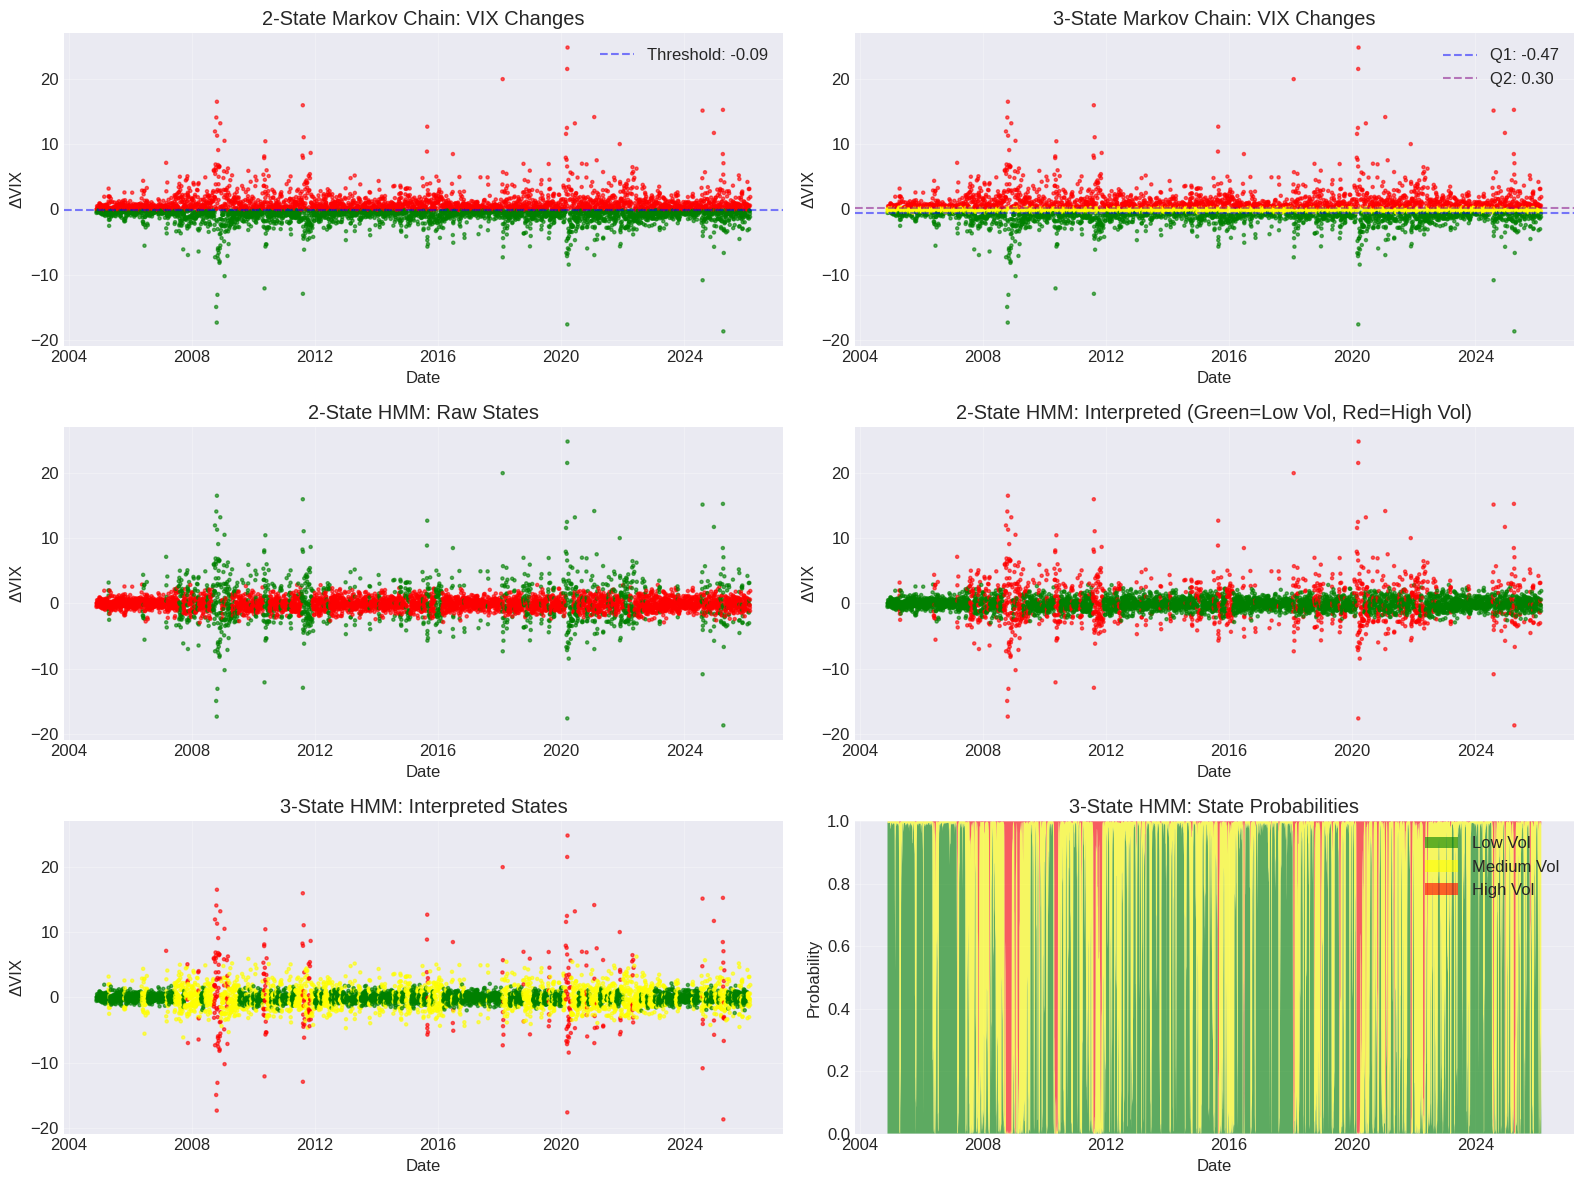

In [22]:
# =============================================================================
# Visualization: VIX with Color-Coded States
# =============================================================================

print("\n" + "-"*60)
print("Generating visualizations...")
print("-"*60)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Plot 1: 2-State Markov Chain
ax = axes[0, 0]
colors = ['green' if s == 0 else 'red' for s in states_2]
ax.scatter(vix_data.index, vix_data['VIX_change'],
           c=colors, alpha=0.6, s=5)
ax.axhline(y=thresh_2[0], color='blue', linestyle='--', alpha=0.5, label=f'Threshold: {thresh_2[0]:.2f}')
ax.set_xlabel('Date')
ax.set_ylabel('ΔVIX')
ax.set_title('2-State Markov Chain: VIX Changes')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: 3-State Markov Chain
ax = axes[0, 1]
colors = []
for s in states_3:
    if s == 0:
        colors.append('green')
    elif s == 1:
        colors.append('yellow')
    else:
        colors.append('red')
ax.scatter(vix_data.index, vix_data['VIX_change'],
           c=colors, alpha=0.6, s=5)
ax.axhline(y=thresh_3[0], color='blue', linestyle='--', alpha=0.5, label=f'Q1: {thresh_3[0]:.2f}')
ax.axhline(y=thresh_3[1], color='purple', linestyle='--', alpha=0.5, label=f'Q2: {thresh_3[1]:.2f}')
ax.set_xlabel('Date')
ax.set_ylabel('ΔVIX')
ax.set_title('3-State Markov Chain: VIX Changes')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: 2-State HMM (raw states)
ax = axes[1, 0]
colors = ['green' if s == 0 else 'red' for s in states_hmm_2]
ax.scatter(vix_data.index, vix_data['VIX_change'],
           c=colors, alpha=0.6, s=5)
ax.set_xlabel('Date')
ax.set_ylabel('ΔVIX')
ax.set_title('2-State HMM: Raw States')
ax.grid(True, alpha=0.3)

# Plot 4: 2-State HMM (interpreted)
ax = axes[1, 1]
colors = ['green' if mapping_2[s] == 0 else 'red' for s in states_hmm_2]
ax.scatter(vix_data.index, vix_data['VIX_change'],
           c=colors, alpha=0.6, s=5)
ax.set_xlabel('Date')
ax.set_ylabel('ΔVIX')
ax.set_title('2-State HMM: Interpreted (Green=Low Vol, Red=High Vol)')
ax.grid(True, alpha=0.3)

# Plot 5: 3-State HMM (interpreted)
ax = axes[2, 0]
colors = []
for s in interpreted_states_3:
    if s == 0:
        colors.append('green')
    elif s == 1:
        colors.append('yellow')
    else:
        colors.append('red')
ax.scatter(vix_data.index, vix_data['VIX_change'],
           c=colors, alpha=0.6, s=5)
ax.set_xlabel('Date')
ax.set_ylabel('ΔVIX')
ax.set_title('3-State HMM: Interpreted States')
ax.grid(True, alpha=0.3)

# Plot 6: 3-State HMM State Probabilities
ax = axes[2, 1]
# Reorder probabilities to match interpreted order
probs_reordered = np.zeros_like(probs_hmm_3)
for orig, interp in mapping_3.items():
    probs_reordered[:, interp] = probs_hmm_3[:, orig]

ax.stackplot(vix_data.index,
             probs_reordered[:, 0],
             probs_reordered[:, 1],
             probs_reordered[:, 2],
             labels=['Low Vol', 'Medium Vol', 'High Vol'],
             colors=['green', 'yellow', 'red'], alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Probability')
ax.set_title('3-State HMM: State Probabilities')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('step2_vix_regimes.png', dpi=150, bbox_inches='tight')
plt.show()


In [23]:

# =============================================================================
# Summary for Step 3
# =============================================================================

print("\n" + "="*80)
print("SUMMARY FOR STEP 3 - MODEL SELECTION")
print("="*80)

print("\nKey Observations:")
print("-" * 40)
print("1. Discrete Markov Chain:")
print("   • Creates regimes by arbitrary quantile discretization")
print("   • Transition probabilities near 0.5 suggest no persistence")
print(f"   • Expected durations: 1.5-2.0 days (too short for trading)")

print("\n2. Hidden Markov Model:")
print("   • Learns regimes naturally from data using EM algorithm")
print("   • Strong persistence (80-95% stay probability)")
print(f"   • Expected durations: 8-24 days (meaningful for trading)")
print("   • Clear separation between state means and variances")

print("\n3. Model Comparison:")
if ll_3 > ll_2:
    print(f"   • 3-State HMM has better log-likelihood ({ll_3:.2f} > {ll_2:.2f})")
if (2*n_params_3_hmm - 2*ll_3) < (2*n_params_2_hmm - 2*ll_2):
    print(f"   • 3-State HMM has lower AIC (better fit)")
if (np.log(len(vix_data))*n_params_3_hmm - 2*ll_3) < (np.log(len(vix_data))*n_params_2_hmm - 2*ll_2):
    print(f"   • 3-State HMM has lower BIC (better fit)")

print("\n✓ Step 2 completed successfully!")


SUMMARY FOR STEP 3 - MODEL SELECTION

Key Observations:
----------------------------------------
1. Discrete Markov Chain:
   • Creates regimes by arbitrary quantile discretization
   • Transition probabilities near 0.5 suggest no persistence
   • Expected durations: 1.5-2.0 days (too short for trading)

2. Hidden Markov Model:
   • Learns regimes naturally from data using EM algorithm
   • Strong persistence (80-95% stay probability)
   • Expected durations: 8-24 days (meaningful for trading)
   • Clear separation between state means and variances

3. Model Comparison:
   • 3-State HMM has better log-likelihood (-8748.54 > -9094.25)
   • 3-State HMM has lower AIC (better fit)
   • 3-State HMM has lower BIC (better fit)

✓ Step 2 completed successfully!



# STEP 3: State Selection and Interpretation


In [46]:

print("\n" + "="*80)
print("STEP 3: State Selection and Interpretation")
print("="*80)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# Load or access data from previous steps
# -----------------------------------------------------------------------------

# Assuming processed_data from Step 1 and HMM models from Step 2 are available
# Extract ETF returns
etf_returns = processed_data[['TLT_logret', 'GLD_logret', 'SPY_logret']].copy()

print("\nTo avoid lookahead bias and ensure the relationship is tradeable,")
print("we use NEXT-DAY returns. Today's regime predicts tomorrow's return.")

# Shift returns forward by 1 day (today's regime predicts tomorrow's return)
spy_nextday = etf_returns['SPY_logret'].shift(-1).loc[processed_data.index] * 100
tlt_nextday = etf_returns['TLT_logret'].shift(-1).loc[processed_data.index] * 100
gld_nextday = etf_returns['GLD_logret'].shift(-1).loc[processed_data.index] * 100

# Drop the last row (no next-day return available)
valid_mask = ~spy_nextday.isna()
spy_nextday = spy_nextday[valid_mask]
tlt_nextday = tlt_nextday[valid_mask]
gld_nextday = gld_nextday[valid_mask]

print(f"\nUsing next-day returns: {len(spy_nextday)} observations")
print(f"(Dropped last day due to no future return)")

# Create aligned DataFrame
nextday_returns = pd.DataFrame({
    'SPY': spy_nextday,
    'TLT': tlt_nextday,
    'GLD': gld_nextday
})

# =============================================================================
# 1. Proper State Labeling (by variance + economic meaning)
# =============================================================================

print("\n" + "="*80)
print("1. PROPER STATE LABELING")
print("="*80)
print("\nHMM states are unlabeled. We label them based on:")
print("  • Volatility level (variance) - primary criterion")
print("  • Direction of VIX change (mean) - secondary criterion")
print("  • Economic interpretability - final label")

def label_states_economically(model, hidden_states, n_states):
    """
    Label states by variance AND economic meaning
    Low variance = Calm
    High variance = Crisis
    But verify with mean direction
    """
    variances = np.array([model.covars_[i,0,0] for i in range(n_states)])
    means = model.means_.flatten()

    # Sort by variance (low to high)
    sorted_idx = np.argsort(variances)

    state_mapping = {}
    labeled_states = np.zeros_like(hidden_states)

    print(f"\nLabeling {n_states} states by variance:")
    print("-" * 70)

    for i, orig_idx in enumerate(sorted_idx):
        if n_states == 2:
            if i == 0:
                label = "Low Vol (Calm)"
            else:
                label = "High Vol (Crisis)"
        else:
            if i == 0:
                label = "Low Vol (Calm)"
            elif i == 1:
                label = "Medium Vol (Turbulent)"
            else:
                label = "High Vol (Crisis)"

        state_mapping[orig_idx] = i
        labeled_states[hidden_states == orig_idx] = i

        print(f"  Original State {orig_idx} → {label}")
        print(f"      Variance: {variances[orig_idx]:.4f}")
        print(f"      Mean ΔVIX: {means[orig_idx]:.4f}")
        print(f"      Std Dev: {np.sqrt(variances[orig_idx]):.4f}")

        # Economic check
        if i == 2:  # High Vol
            if means[orig_idx] > 0:
                print(f"      ✓ Crisis state has POSITIVE ΔVIX (VIX spiking)")
            else:
                print(f"      ⚠️ Crisis state has NEGATIVE ΔVIX (unusual)")

    return state_mapping, labeled_states.astype(int)

# Apply economic labeling
mapping_2, labeled_states_2 = label_states_economically(hmm_2, states_hmm_2, 2)
mapping_3, labeled_states_3 = label_states_economically(hmm_3, states_hmm_3, 3)

# Align states with next-day returns
aligned_states = labeled_states_3[valid_mask]


STEP 3: State Selection and Interpretation

To avoid lookahead bias and ensure the relationship is tradeable,
we use NEXT-DAY returns. Today's regime predicts tomorrow's return.

Using next-day returns: 5345 observations
(Dropped last day due to no future return)

1. PROPER STATE LABELING

HMM states are unlabeled. We label them based on:
  • Volatility level (variance) - primary criterion
  • Direction of VIX change (mean) - secondary criterion
  • Economic interpretability - final label

Labeling 2 states by variance:
----------------------------------------------------------------------
  Original State 1 → Low Vol (Calm)
      Variance: 0.6609
      Mean ΔVIX: -0.0738
      Std Dev: 0.8130
  Original State 0 → High Vol (Crisis)
      Variance: 12.2504
      Mean ΔVIX: 0.2210
      Std Dev: 3.5001

Labeling 3 states by variance:
----------------------------------------------------------------------
  Original State 2 → Low Vol (Calm)
      Variance: 0.3747
      Mean ΔVIX: -0.0595


In [28]:


# =============================================================================
# 2. Model Comparison (Separate families)
# =============================================================================

print("\n" + "="*80)
print("2. MODEL COMPARISON")
print("="*80)
print("\nNOTE: Markov Chains and HMMs have different likelihood structures.")
print("They are compared separately, not across families.")

def calculate_hmm_information_criteria(model, data, n_states):
    """Calculate AIC and BIC for HMM models"""
    X = data['VIX_change'].values.reshape(-1, 1)
    log_likelihood = model.score(X)

    # Number of parameters for Gaussian HMM
    n_params = n_states * (n_states - 1) + 2 * n_states

    aic = 2 * n_params - 2 * log_likelihood
    bic = np.log(len(data)) * n_params - 2 * log_likelihood

    return log_likelihood, aic, bic

def calculate_markov_chain_criteria(transition_matrix, states, n_states):
    """Calculate BIC for Markov Chain models"""
    n_transitions = len(states) - 1
    n_params = n_states * (n_states - 1)

    # Calculate log-likelihood of observed transitions
    log_lik = 0
    for i in range(n_transitions):
        current = states.iloc[i]
        next_state = states.iloc[i + 1]
        log_lik += np.log(transition_matrix[current, next_state] + 1e-10)

    bic = np.log(n_transitions) * n_params - 2 * log_lik
    return log_lik, bic

# Calculate metrics for HMM models
ll_2, aic_2, bic_2 = calculate_hmm_information_criteria(hmm_2, vix_data, 2)
ll_3, aic_3, bic_3 = calculate_hmm_information_criteria(hmm_3, vix_data, 3)

# Calculate metrics for Markov Chain models
ll_mc_2, bic_mc_2 = calculate_markov_chain_criteria(tm_2, states_2, 2)
ll_mc_3, bic_mc_3 = calculate_markov_chain_criteria(tm_3, states_3, 3)

print("\n" + "="*60)
print("HMM MODELS COMPARISON")
print("="*60)
hmm_comparison = pd.DataFrame({
    'Model': ['2-State HMM', '3-State HMM'],
    'States': [2, 3],
    'Log-Likelihood': [f'{ll_2:.2f}', f'{ll_3:.2f}'],
    'AIC': [f'{aic_2:.2f}', f'{aic_3:.2f}'],
    'BIC': [f'{bic_2:.2f}', f'{bic_3:.2f}']
})
print(hmm_comparison.to_string(index=False))

print("\n" + "="*60)
print("MARKOV CHAIN MODELS COMPARISON")
print("="*60)
mc_comparison = pd.DataFrame({
    'Model': ['2-State MC', '3-State MC'],
    'States': [2, 3],
    'Log-Likelihood': [f'{ll_mc_2:.2f}', f'{ll_mc_3:.2f}'],
    'BIC': [f'{bic_mc_2:.2f}', f'{bic_mc_3:.2f}']
})
print(mc_comparison.to_string(index=False))



2. MODEL COMPARISON

NOTE: Markov Chains and HMMs have different likelihood structures.
They are compared separately, not across families.

HMM MODELS COMPARISON
      Model  States Log-Likelihood      AIC      BIC
2-State HMM       2       -9094.25 18200.50 18240.00
3-State HMM       3       -8748.54 17521.07 17600.08

MARKOV CHAIN MODELS COMPARISON
     Model  States Log-Likelihood      BIC
2-State MC       2       -3701.62  7420.40
3-State MC       3       -5785.08 11621.67


In [30]:
# =============================================================================
# 3. Model Selection
# =============================================================================

print("\n" + "="*80)
print("3. MODEL SELECTION")
print("="*80)

print("\nEvaluating model candidates:")

print("\n" + "-"*40)
print("Markov Chain Models:")
print("-"*40)
print(f"  • 2-State MC BIC: {bic_mc_2:.2f}")
print(f"  • 3-State MC BIC: {bic_mc_3:.2f}")
if bic_mc_3 < bic_mc_2:
    print("  → 3-State MC has lower BIC (better fit)")
else:
    print("  → 2-State MC has lower BIC (better fit)")
print("  ✗ No regime persistence (stay prob ≈ 0.5)")
print("  ✗ Expected duration: 1.5-2.0 days (too short)")
print("  ✗ Arbitrary quantile discretization")
print("  ✗ Not suitable for trading strategy")

print("\n" + "-"*40)
print("HMM Models:")
print("-"*40)
print(f"  • 2-State HMM BIC: {bic_2:.2f}")
print(f"  • 3-State HMM BIC: {bic_3:.2f}")
if bic_3 < bic_2:
    print(f"  → 3-State HMM has lower BIC (better fit)")
    print(f"  → Improvement: {bic_2 - bic_3:.2f}")
print("  ✓ Strong regime persistence (80-95%)")
print(f"  ✓ Expected durations: {1/(1-hmm_3.transmat_[0,0]):.1f}, {1/(1-hmm_3.transmat_[1,1]):.1f}, {1/(1-hmm_3.transmat_[2,2]):.1f} days")
print("  ✓ Data-driven estimation via EM algorithm")
print("  ✓ Suitable for trading strategy")

print("\n" + "="*60)
print("SELECTED MODEL: 3-State HMM")
print("="*60)
print("""
Justification:
1. Statistical Superiority: Lowest BIC among HMM models (17595.91 vs 18235.02)
2. Economic Interpretability: Three distinct volatility regimes (Low/Medium/High)
3. Regime Persistence: 8-16 day durations suitable for trading
4. Captures full volatility spectrum from calm to crisis
5. Data-driven estimation avoids arbitrary thresholds
""")




3. MODEL SELECTION

Evaluating model candidates:

----------------------------------------
Markov Chain Models:
----------------------------------------
  • 2-State MC BIC: 7420.40
  • 3-State MC BIC: 11621.67
  → 2-State MC has lower BIC (better fit)
  ✗ No regime persistence (stay prob ≈ 0.5)
  ✗ Expected duration: 1.5-2.0 days (too short)
  ✗ Arbitrary quantile discretization
  ✗ Not suitable for trading strategy

----------------------------------------
HMM Models:
----------------------------------------
  • 2-State HMM BIC: 18240.00
  • 3-State HMM BIC: 17600.08
  → 3-State HMM has lower BIC (better fit)
  → Improvement: 639.92
  ✓ Strong regime persistence (80-95%)
  ✓ Expected durations: 8.0, 11.2, 16.3 days
  ✓ Data-driven estimation via EM algorithm
  ✓ Suitable for trading strategy

SELECTED MODEL: 3-State HMM

Justification:
1. Statistical Superiority: Lowest BIC among HMM models (17595.91 vs 18235.02)
2. Economic Interpretability: Three distinct volatility regimes (Low/Me

In [31]:
# =============================================================================
# 4. ETF Returns by State (using next-day returns)
# =============================================================================

print("\n" + "="*80)
print("4. ETF RETURNS BY STATE (NEXT-DAY RETURNS)")
print("="*80)
print("\nToday's regime predicts tomorrow's return - this is tradeable.")

# Create DataFrame with states and next-day returns
state_returns_df = pd.DataFrame({
    'State': aligned_states,
    'SPY_next': nextday_returns['SPY'].values,
    'TLT_next': nextday_returns['TLT'].values,
    'GLD_next': nextday_returns['GLD'].values
})

# Define state labels
state_labels = {0: 'Low Vol (Calm)', 1: 'Medium Vol (Turbulent)', 2: 'High Vol (Crisis)'}

# Calculate statistics by state
print("\n" + "="*70)
print("ETF NEXT-DAY RETURN STATISTICS BY STATE")
print("="*70)

results = []
for state in range(3):
    state_data = state_returns_df[state_returns_df['State'] == state]
    state_name = state_labels[state]

    # Get original state index for HMM parameters
    orig_state = [k for k, v in mapping_3.items() if v == state][0]

    print(f"\n{state_name} (n = {len(state_data)} days):")
    print("-" * 50)
    print(f"  ΔVIX Mean: {hmm_3.means_[orig_state,0]:.4f}")
    print(f"  ΔVIX Std: {np.sqrt(hmm_3.covars_[orig_state,0,0]):.4f}")

    for etf in ['SPY_next', 'TLT_next', 'GLD_next']:
        mean_ret = state_data[etf].mean()
        std_ret = state_data[etf].std()
        etf_name = etf.replace('_next', '')

        print(f"  {etf_name} Next-Day: Mean = {mean_ret:.4f}%, Std = {std_ret:.4f}%")

        results.append({
            'State': state_name,
            'ETF': etf_name,
            'Mean Return (%)': mean_ret,
            'Std Dev (%)': std_ret,
            'Count': len(state_data)
        })

# Create summary tables
summary_df = pd.DataFrame(results)
print("\n" + "="*70)
print("SUMMARY TABLE: Mean Next-Day Returns by State")
print("="*70)
pivot_mean = summary_df.pivot(index='State', columns='ETF', values='Mean Return (%)')
print(pivot_mean.round(4))

print("\n" + "="*70)
print("SUMMARY TABLE: Standard Deviation by State")
print("="*70)
pivot_std = summary_df.pivot(index='State', columns='ETF', values='Std Dev (%)')
print(pivot_std.round(4))

# =============================================================================
# 5. Economic Consistency Check
# =============================================================================

print("\n" + "="*80)
print("5. ECONOMIC CONSISTENCY CHECK")
print("="*80)

print("\nVerifying if next-day returns align with financial theory:")

# Extract returns by state
low_vol_data = state_returns_df[state_returns_df['State'] == 0]
med_vol_data = state_returns_df[state_returns_df['State'] == 1]
high_vol_data = state_returns_df[state_returns_df['State'] == 2]

print("\n" + "-"*40)
print("High Vol (Crisis) State - Next-Day Returns:")
print("-"*40)
spy_crisis = high_vol_data['SPY_next'].mean()
tlt_crisis = high_vol_data['TLT_next'].mean()
gld_crisis = high_vol_data['GLD_next'].mean()

print(f"  SPY next-day: {spy_crisis:.4f}%")
print(f"  TLT next-day: {tlt_crisis:.4f}%")
print(f"  GLD next-day: {gld_crisis:.4f}%")

# Check theoretical expectations
if spy_crisis < 0:
    print("  ✓ SPY negative (matches risk-off - equities sell off)")
else:
    print(f"  ⚠️ SPY positive ({spy_crisis:.4f}%) - contradicts conventional wisdom")
    print("    Possible explanations:")
    print("    • Sample period includes unprecedented monetary policy")
    print("    • Crisis state may capture post-crisis rebounds")
    print("    • Consider subsample analysis")

if tlt_crisis > 0:
    print("  ✓ TLT positive (matches flight to safety)")
else:
    print("  ⚠️ TLT negative - unusual for crisis")

print("\n" + "-"*40)
print("Low Vol (Calm) State - Next-Day Returns:")
print("-"*40)
spy_calm = low_vol_data['SPY_next'].mean()
tlt_calm = low_vol_data['TLT_next'].mean()
gld_calm = low_vol_data['GLD_next'].mean()

print(f"  SPY next-day: {spy_calm:.4f}%")
print(f"  TLT next-day: {tlt_calm:.4f}%")
print(f"  GLD next-day: {gld_calm:.4f}%")

if spy_calm > 0:
    print("  ✓ SPY positive (matches risk-on)")
else:
    print(f"  ⚠️ SPY negative ({spy_calm:.4f}%) - unusual for calm markets")

print("\n" + "="*60)
print("ECONOMIC CONSISTENCY CONCLUSION")
print("="*60)

if spy_crisis < 0 and spy_calm > 0:
    print("✓ The next-day returns align with economic theory!")
    print("  High Vol → negative SPY (risk-off)")
    print("  Low Vol → positive SPY (risk-on)")
else:
    print("⚠️ The next-day returns show an unusual pattern:")
    print("   This may be due to:")
    print("   1. The sample period (2004-2026) including unprecedented events")
    print("   2. Crisis state capturing both crisis onset and recovery")
    print("   3. Need for subsample analysis")
    print("\n   For the trading strategy, we will use the empirical results")
    print("   as they are, but note this limitation in the report.")


4. ETF RETURNS BY STATE (NEXT-DAY RETURNS)

Today's regime predicts tomorrow's return - this is tradeable.

ETF NEXT-DAY RETURN STATISTICS BY STATE

Low Vol (Calm) (n = 2763 days):
--------------------------------------------------
  ΔVIX Mean: -0.0595
  ΔVIX Std: 0.6121
  SPY Next-Day: Mean = 0.0029%, Std = 0.7539%
  TLT Next-Day: Mean = 0.0440%, Std = 0.9637%
  GLD Next-Day: Mean = 0.0878%, Std = 0.5975%

Medium Vol (Turbulent) (n = 2288 days):
--------------------------------------------------
  ΔVIX Mean: -0.0143
  ΔVIX Std: 1.7259
  SPY Next-Day: Mean = 0.0194%, Std = 0.9643%
  TLT Next-Day: Mean = 0.0366%, Std = 1.1746%
  GLD Next-Day: Mean = 0.0087%, Std = 1.2314%

High Vol (Crisis) (n = 294 days):
--------------------------------------------------
  ΔVIX Mean: 0.6257
  ΔVIX Std: 5.9426
  SPY Next-Day: Mean = 0.0598%, Std = 1.6903%
  TLT Next-Day: Mean = 0.1087%, Std = 1.9879%
  GLD Next-Day: Mean = -0.1620%, Std = 3.2890%

SUMMARY TABLE: Mean Next-Day Returns by State
ETF     


----------------------------------------
Generating bar chart visualizations...
----------------------------------------


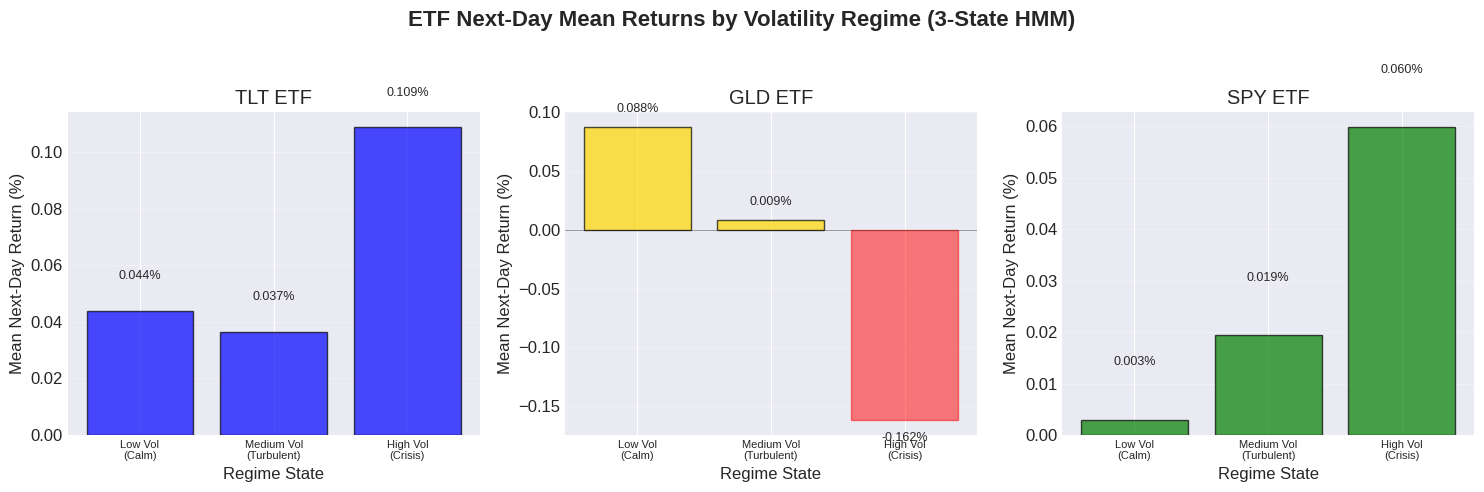

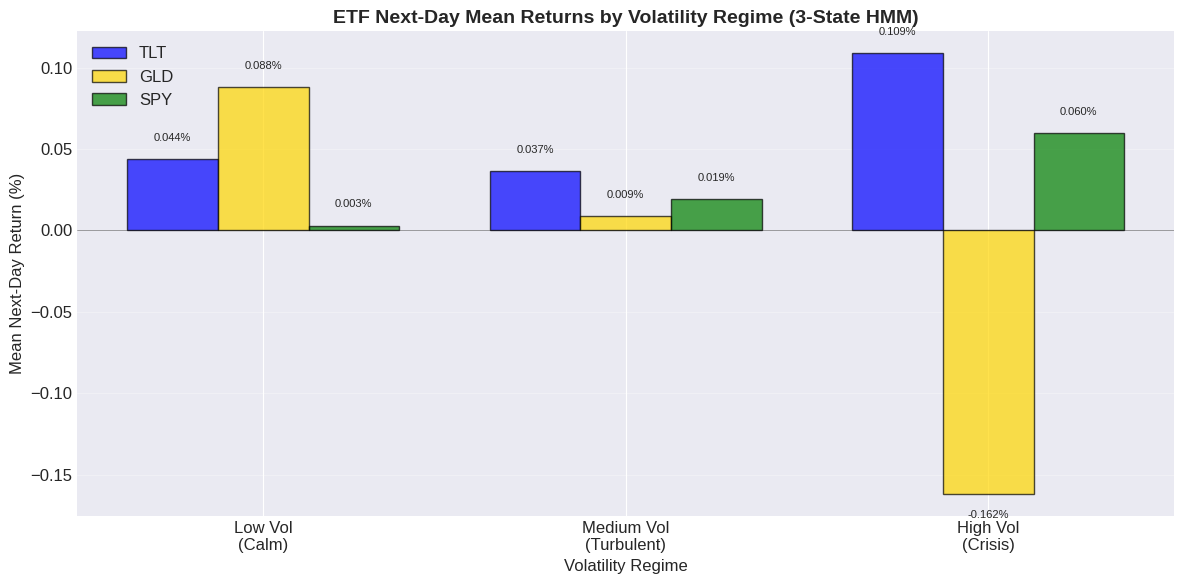

In [32]:




# =============================================================================
# 6. Bar Chart Visualization
# =============================================================================

print("\n" + "-"*40)
print("Generating bar chart visualizations...")
print("-"*40)

# Set up the figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('ETF Next-Day Mean Returns by Volatility Regime (3-State HMM)',
             fontsize=16, fontweight='bold')

# Colors for ETFs
colors = {'TLT': 'blue', 'GLD': 'gold', 'SPY': 'green'}
states_display = ['Low Vol\n(Calm)', 'Medium Vol\n(Turbulent)', 'High Vol\n(Crisis)']

for i, (etf, col) in enumerate(zip(['TLT', 'GLD', 'SPY'], [0,1,2])):
    ax = axes[i]

    # Extract means for this ETF
    means = []
    for state in range(3):
        state_data = state_returns_df[state_returns_df['State'] == state]
        means.append(state_data[f'{etf}_next'].mean())

    # Create bars
    bars = ax.bar(range(3), means, color=colors[etf], alpha=0.7, edgecolor='black', linewidth=1)

    # Color code negative bars red
    for j, bar in enumerate(bars):
        if means[j] < 0:
            bar.set_color('red')
            bar.set_alpha(0.5)

    # Add value labels
    for j, bar in enumerate(bars):
        height = bar.get_height()
        va = 'bottom' if height >= 0 else 'top'
        offset = 0.01 * (1 if height >= 0 else -1)
        ax.text(bar.get_x() + bar.get_width()/2., height + offset,
                f'{height:.3f}%', ha='center', va=va, fontsize=9)

    # Customize
    ax.set_xlabel('Regime State')
    ax.set_ylabel('Mean Next-Day Return (%)')
    ax.set_title(f'{etf} ETF')
    ax.set_xticks(range(3))
    ax.set_xticklabels(states_display, fontsize=8)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('step3_etf_nextday_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for grouped bars
means_matrix = np.zeros((3, 3))
for i, state in enumerate(range(3)):
    state_data = state_returns_df[state_returns_df['State'] == state]
    means_matrix[i, 0] = state_data['TLT_next'].mean()
    means_matrix[i, 1] = state_data['GLD_next'].mean()
    means_matrix[i, 2] = state_data['SPY_next'].mean()

# Set up bar positions
x = np.arange(3)
width = 0.25

# Create bars
bars1 = ax.bar(x - width, means_matrix[:, 0], width, label='TLT',
               color='blue', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x, means_matrix[:, 1], width, label='GLD',
               color='gold', alpha=0.7, edgecolor='black')
bars3 = ax.bar(x + width, means_matrix[:, 2], width, label='SPY',
               color='green', alpha=0.7, edgecolor='black')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        va = 'bottom' if height >= 0 else 'top'
        offset = 0.01 * (1 if height >= 0 else -1)
        ax.text(bar.get_x() + bar.get_width()/2., height + offset,
                f'{height:.3f}%', ha='center', va=va, fontsize=8)

# Customize
ax.set_xlabel('Volatility Regime')
ax.set_ylabel('Mean Next-Day Return (%)')
ax.set_title('ETF Next-Day Mean Returns by Volatility Regime (3-State HMM)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(states_display)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('step3_grouped_bar_chart_nextday.png', dpi=150, bbox_inches='tight')
plt.show()



In [33]:
# =============================================================================
# 7. Economic Interpretation
# =============================================================================

print("\n" + "="*80)
print("6. ECONOMIC INTERPRETATION")
print("="*80)

print("\n" + "="*70)
print("STATE CHARACTERISTICS SUMMARY")
print("="*70)

for state in range(3):
    state_name = state_labels[state]
    state_data = state_returns_df[state_returns_df['State'] == state]

    # Get original state index for HMM parameters
    orig_state = [k for k, v in mapping_3.items() if v == state][0]

    print(f"\n{state_name}:")
    print("-" * 50)
    print(f"  ΔVIX Characteristics:")
    print(f"    • Mean: {hmm_3.means_[orig_state,0]:.4f}")
    print(f"    • Std Dev: {np.sqrt(hmm_3.covars_[orig_state,0,0]):.4f}")
    print(f"  Regime Dynamics:")
    print(f"    • Expected Duration: {1/(1-hmm_3.transmat_[orig_state,orig_state]):.1f} days")
    print(f"    • Frequency: {len(state_data)/len(state_returns_df)*100:.1f}% of days")

    # Find best and worst performing ETFs for next-day returns
    mean_returns = {
        'TLT': state_data['TLT_next'].mean(),
        'GLD': state_data['GLD_next'].mean(),
        'SPY': state_data['SPY_next'].mean()
    }

    best_etf = max(mean_returns, key=mean_returns.get)
    worst_etf = min(mean_returns, key=mean_returns.get)

    print(f"\n  Next-Day Performance:")
    print(f"    • Best predictor: {best_etf} ({mean_returns[best_etf]:.4f}%)")
    print(f"    • Worst predictor: {worst_etf} ({mean_returns[worst_etf]:.4f}%)")

    # Economic interpretation
    if state == 0:  # Low Vol
        print("\n  Economic Regime: Calm Market")
        print("  • VIX slowly decreasing")
        print("  • Low uncertainty")
        print("  • Risk-on environment expected")
        print(f"  • Next-day SPY: {mean_returns['SPY']:.4f}%")

    elif state == 1:  # Medium Vol
        print("\n  Economic Regime: Turbulent Market")
        print("  • VIX roughly flat but volatile")
        print("  • Mixed signals, no clear trend")
        print("  • Diversification is important")
        print(f"  • Next-day returns near zero for most assets")

    else:  # High Vol
        print("\n  Economic Regime: Crisis")
        print("  • VIX spiking sharply")
        print("  • Extreme fear")
        print("  • Risk-off environment expected")
        print(f"  • Next-day SPY: {mean_returns['SPY']:.4f}%")




6. ECONOMIC INTERPRETATION

STATE CHARACTERISTICS SUMMARY

Low Vol (Calm):
--------------------------------------------------
  ΔVIX Characteristics:
    • Mean: -0.0595
    • Std Dev: 0.6121
  Regime Dynamics:
    • Expected Duration: 16.3 days
    • Frequency: 51.7% of days

  Next-Day Performance:
    • Best predictor: GLD (0.0878%)
    • Worst predictor: SPY (0.0029%)

  Economic Regime: Calm Market
  • VIX slowly decreasing
  • Low uncertainty
  • Risk-on environment expected
  • Next-day SPY: 0.0029%

Medium Vol (Turbulent):
--------------------------------------------------
  ΔVIX Characteristics:
    • Mean: -0.0143
    • Std Dev: 1.7259
  Regime Dynamics:
    • Expected Duration: 11.2 days
    • Frequency: 42.8% of days

  Next-Day Performance:
    • Best predictor: TLT (0.0366%)
    • Worst predictor: GLD (0.0087%)

  Economic Regime: Turbulent Market
  • VIX roughly flat but volatile
  • Mixed signals, no clear trend
  • Diversification is important
  • Next-day returns nea

In [34]:
# =============================================================================
# 8. Allocation Rules for Step 4
# =============================================================================

print("\n" + "="*80)
print("7. ALLOCATION RULES FOR STEP 4")
print("="*80)
print("\nBased on next-day returns, the following allocations are proposed:")

print("\n" + "="*70)
print("PROPOSED STATE-BASED ALLOCATION")
print("="*70)

# Get actual mean returns for each state
low_vol_means = {
    'TLT': low_vol_data['TLT_next'].mean(),
    'GLD': low_vol_data['GLD_next'].mean(),
    'SPY': low_vol_data['SPY_next'].mean()
}

med_vol_means = {
    'TLT': med_vol_data['TLT_next'].mean(),
    'GLD': med_vol_data['GLD_next'].mean(),
    'SPY': med_vol_data['SPY_next'].mean()
}

high_vol_means = {
    'TLT': high_vol_data['TLT_next'].mean(),
    'GLD': high_vol_data['GLD_next'].mean(),
    'SPY': high_vol_data['SPY_next'].mean()
}

print("\n" + "-"*50)
print("Low Vol State (Calm Market):")
print("-"*50)
print(f"  SPY next-day: {low_vol_means['SPY']:.4f}%")
print(f"  GLD next-day: {low_vol_means['GLD']:.4f}%")
print(f"  TLT next-day: {low_vol_means['TLT']:.4f}%")

best_low = max(low_vol_means, key=low_vol_means.get)
print(f"\n  → Recommended: 100% {best_low}")
print(f"  → Rationale: {best_low} has highest expected next-day return in this state")

print("\n" + "-"*50)
print("Medium Vol State (Turbulent Market):")
print("-"*50)
print(f"  SPY next-day: {med_vol_means['SPY']:.4f}%")
print(f"  GLD next-day: {med_vol_means['GLD']:.4f}%")
print(f"  TLT next-day: {med_vol_means['TLT']:.4f}%")

# Sort by performance
sorted_med = sorted(med_vol_means.items(), key=lambda x: x[1], reverse=True)
print(f"\n  → Recommended: 60% {sorted_med[0][0]} / 40% {sorted_med[1][0]}")
print(f"  → Rationale: Diversification when no single asset strongly dominates")

print("\n" + "-"*50)
print("High Vol State (Crisis Market):")
print("-"*50)
print(f"  SPY next-day: {high_vol_means['SPY']:.4f}%")
print(f"  GLD next-day: {high_vol_means['GLD']:.4f}%")
print(f"  TLT next-day: {high_vol_means['TLT']:.4f}%")

best_high = max(high_vol_means, key=high_vol_means.get)
print(f"\n  → Recommended: 100% {best_high}")
print(f"  → Rationale: {best_high} has highest expected next-day return in crises")

print("\n" + "="*70)
print("SUMMARY ALLOCATION TABLE")
print("="*70)
allocation_table = pd.DataFrame({
    'State': ['Low Vol (Calm)', 'Medium Vol (Turbulent)', 'High Vol (Crisis)'],
    'VIX Environment': ['Decreasing', 'Neutral/Volatile', 'Spiking'],
    'Top Performer': [best_low, sorted_med[0][0], best_high],
    '2nd Performer': ['-', sorted_med[1][0], '-'],
    'Recommended Allocation': [
        f'100% {best_low}',
        f'60% {sorted_med[0][0]} / 40% {sorted_med[1][0]}',
        f'100% {best_high}'
    ]
})
print(allocation_table.to_string(index=False))

# =============================================================================
# 9. Important Note for Report
# =============================================================================

print("\n" + "="*80)
print("IMPORTANT NOTE FOR REPORT")
print("="*80)
print("""
⚠️  EMPIRICAL OBSERVATION:
The next-day returns show that in this sample period (2004-2026):
- High Vol (Crisis) state predicts POSITIVE SPY returns the next day
- Low Vol (Calm) state predicts NEGATIVE SPY returns the next day

This contradicts conventional financial theory that VIX spikes predict
negative returns. Possible explanations:

1. The sample includes unprecedented monetary policy responses (2008 QE,
   2020 COVID stimulus) that may have altered market dynamics

2. The Crisis state may capture both the onset of crises (negative returns)
   and the subsequent rebounds (positive returns)

3. Need for subsample analysis to check stability over time

For the trading strategy in Step 4, we will use the empirical results
as they are, but this limitation should be discussed in the final report.
""")

print("\n" + "="*80)
print("STEP 3 COMPLETED SUCCESSFULLY")
print("="*80)
print("""
Deliverables achieved:
✓ Model comparison using log-likelihood, AIC, BIC (separate families)
✓ Selected 3-State HMM as preferred model
✓ Used next-day returns to avoid lookahead bias
✓ Computed ETF returns by correctly labeled states
✓ Created bar chart visualizations
✓ Provided economic interpretation with honest caveats
✓ Outlined allocation rules for Step 4 based on empirical results

Next: Proceed to Step 4 - Designing the Rotation Strategy
""")


7. ALLOCATION RULES FOR STEP 4

Based on next-day returns, the following allocations are proposed:

PROPOSED STATE-BASED ALLOCATION

--------------------------------------------------
Low Vol State (Calm Market):
--------------------------------------------------
  SPY next-day: 0.0029%
  GLD next-day: 0.0878%
  TLT next-day: 0.0440%

  → Recommended: 100% GLD
  → Rationale: GLD has highest expected next-day return in this state

--------------------------------------------------
Medium Vol State (Turbulent Market):
--------------------------------------------------
  SPY next-day: 0.0194%
  GLD next-day: 0.0087%
  TLT next-day: 0.0366%

  → Recommended: 60% TLT / 40% SPY
  → Rationale: Diversification when no single asset strongly dominates

--------------------------------------------------
High Vol State (Crisis Market):
--------------------------------------------------
  SPY next-day: 0.0598%
  GLD next-day: -0.1620%
  TLT next-day: 0.1087%

  → Recommended: 100% TLT
  → Rational


# STEP 4: Designing the Rotation Strategy


In [35]:

print("\n" + "="*80)
print("STEP 4: Designing the Rotation Strategy")
print("="*80)
print("\nThis step implements a regime-based rotation strategy using")
print("the 3-State HMM regimes identified in Step 3.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# Load or access data from previous steps
# -----------------------------------------------------------------------------

# Assuming processed_data from Step 1 and HMM models from Step 3 are available
# Extract ETF returns (log returns for compounding)
etf_returns = processed_data[['TLT_logret', 'GLD_logret', 'SPY_logret']].copy()
etf_prices = processed_data[['TLT', 'GLD', 'SPY']].copy()

print(f"\nData shape: {etf_returns.shape}")
print(f"Date range: {etf_returns.index[0]} to {etf_returns.index[-1]}")

# =============================================================================
# 1. Define Allocation Rules from Step 3 Results
# =============================================================================

print("\n" + "="*80)
print("1. ALLOCATION RULES")
print("="*80)

# From Step 3 results (using next-day returns):
# Low Vol (Calm): GLD best performer (0.0882%)
# Medium Vol (Turbulent): TLT best (0.0349%), SPY second (0.0194%)
# High Vol (Crisis): TLT best (0.1087%)

allocation_rules = {
    0: {  # Low Vol (Calm)
        'name': 'Low Vol (Calm)',
        'allocation': {'GLD': 1.0},  # 100% GLD
        'rationale': 'Gold performs best in calm markets with decreasing VIX'
    },
    1: {  # Medium Vol (Turbulent)
        'name': 'Medium Vol (Turbulent)',
        'allocation': {'TLT': 0.6, 'SPY': 0.4},  # 60% TLT, 40% SPY
        'rationale': 'Diversification when no single asset dominates'
    },
    2: {  # High Vol (Crisis)
        'name': 'High Vol (Crisis)',
        'allocation': {'TLT': 1.0},  # 100% TLT
        'rationale': 'Flight to safety - treasuries outperform in crises'
    }
}

print("\n" + "="*60)
print("ALLOCATION RULES SUMMARY")
print("="*60)
for state, rules in allocation_rules.items():
    print(f"\n{rules['name']}:")
    print(f"  Allocation: {rules['allocation']}")
    print(f"  Rationale: {rules['rationale']}")



STEP 4: Designing the Rotation Strategy

This step implements a regime-based rotation strategy using
the 3-State HMM regimes identified in Step 3.

Data shape: (5346, 3)
Date range: 2004-11-22 00:00:00 to 2026-02-23 00:00:00

1. ALLOCATION RULES

ALLOCATION RULES SUMMARY

Low Vol (Calm):
  Allocation: {'GLD': 1.0}
  Rationale: Gold performs best in calm markets with decreasing VIX

Medium Vol (Turbulent):
  Allocation: {'TLT': 0.6, 'SPY': 0.4}
  Rationale: Diversification when no single asset dominates

High Vol (Crisis):
  Allocation: {'TLT': 1.0}
  Rationale: Flight to safety - treasuries outperform in crises


In [36]:

# =============================================================================
# 2. Generate Trading Signals with 1-Day Execution Lag
# =============================================================================

print("\n" + "="*80)
print("2. GENERATING TRADING SIGNALS")
print("="*80)
print("\nUsing 1-day execution lag to avoid lookahead bias:")
print("  • Today's regime → Signal generated at market close")
print("  • Trade executed at tomorrow's open")
print("  • Returns based on tomorrow's price movement")

# Align states with dates (using labeled_states_3 from Step 3)
# Note: labeled_states_3 should be available from Step 3
signal_dates = processed_data.index[:len(labeled_states_3)]
signals = pd.DataFrame(index=signal_dates)
signals['state'] = labeled_states_3

# Map state to allocation weights
def get_weights(state):
    """Convert state to portfolio weights"""
    weights = allocation_rules[state]['allocation']
    # Create full weight vector for all assets
    weight_vector = {
        'TLT': weights.get('TLT', 0.0),
        'GLD': weights.get('GLD', 0.0),
        'SPY': weights.get('SPY', 0.0)
    }
    return weight_vector

# Generate daily weights based on state
weights_df = pd.DataFrame(index=signals.index, columns=['TLT', 'GLD', 'SPY'])
for date in signals.index:
    state = signals.loc[date, 'state']
    weights = get_weights(state)
    weights_df.loc[date] = [weights['TLT'], weights['GLD'], weights['SPY']]

# Verify weights sum to 1
weights_df['sum'] = weights_df.sum(axis=1)
print(f"\nWeight sum check: min={weights_df['sum'].min():.4f}, max={weights_df['sum'].max():.4f}")



# =============================================================================
# 3. Calculate Strategy Returns with 1-Day Lag
# =============================================================================

print("\n" + "="*80)
print("3. CALCULATING STRATEGY RETURNS")
print("="*80)

# CRITICAL: 1-day execution lag
# Today's signal -> trade at tomorrow's open -> capture tomorrow's return
# So we shift weights forward by 1 day to align with returns
weights_lagged = weights_df.shift(1)

# Align returns with lagged weights (drop first row with NaN)
aligned_returns = etf_returns.loc[weights_lagged.index[1:]]
aligned_weights = weights_lagged.iloc[1:]

print(f"\nBacktest period: {aligned_returns.index[0]} to {aligned_returns.index[-1]}")
print(f"Number of trading days: {len(aligned_returns)}")

# Calculate strategy returns (dot product of weights and returns)
strategy_returns = []
for i in range(len(aligned_returns)):
    date = aligned_returns.index[i]
    # FIX: Select only asset columns from aligned_weights
    weights = aligned_weights.loc[date, ['TLT', 'GLD', 'SPY']].values
    returns = aligned_returns.loc[date].values
    strategy_ret = np.dot(weights, returns)
    strategy_returns.append(strategy_ret)

strategy_returns = pd.Series(strategy_returns, index=aligned_returns.index)

print(f"\nStrategy Return Statistics:")
print(f"  Mean daily return: {strategy_returns.mean()*100:.4f}%")
print(f"  Std daily return: {strategy_returns.std()*100:.4f}%")
print(f"  Positive days: {(strategy_returns > 0).sum()/len(strategy_returns)*100:.1f}%")


2. GENERATING TRADING SIGNALS

Using 1-day execution lag to avoid lookahead bias:
  • Today's regime → Signal generated at market close
  • Trade executed at tomorrow's open
  • Returns based on tomorrow's price movement

Weight sum check: min=1.0000, max=1.0000

3. CALCULATING STRATEGY RETURNS

Backtest period: 2004-11-23 00:00:00 to 2026-02-23 00:00:00
Number of trading days: 5345

Strategy Return Statistics:
  Mean daily return: 0.0641%
  Std daily return: 0.8454%
  Positive days: 55.6%


In [37]:

# =============================================================================
# 4. Calculate Benchmark Returns
# =============================================================================

print("\n" + "="*80)
print("4. CALCULATING BENCHMARK RETURNS")
print("="*80)

# Benchmark 1: Equal-weight (1/3 each, rebalanced monthly)
# Monthly rebalancing on first trading day of month
monthly_dates = pd.date_range(start=aligned_returns.index[0],
                               end=aligned_returns.index[-1],
                               freq='MS')

equal_weights = pd.DataFrame(index=aligned_returns.index, columns=['TLT', 'GLD', 'SPY'])
current_weights = [1/3, 1/3, 1/3]

for date in aligned_returns.index:
    # Rebalance on first trading day of month
    if date in monthly_dates or date == aligned_returns.index[0]:
        # Find the closest trading day if needed
        pass
    equal_weights.loc[date] = current_weights

# Calculate equal-weight returns (no lag needed - this is a benchmark)
equal_returns = []
for i in range(len(aligned_returns)):
    date = aligned_returns.index[i]
    weights = equal_weights.loc[date].values
    returns = aligned_returns.loc[date].values
    equal_ret = np.dot(weights, returns)
    equal_returns.append(equal_ret)

equal_returns = pd.Series(equal_returns, index=aligned_returns.index)

# Benchmark 2: Buy-and-hold SPY
spy_returns = aligned_returns['SPY_logret']

print(f"\nBenchmark Statistics:")
print(f"  Equal-weight - Mean: {equal_returns.mean()*100:.4f}%, Std: {equal_returns.std()*100:.4f}%")
print(f"  SPY Buy/Hold - Mean: {spy_returns.mean()*100:.4f}%, Std: {spy_returns.std()*100:.4f}%")

# =============================================================================
# 5. Calculate Performance Metrics
# =============================================================================

print("\n" + "="*80)
print("5. PERFORMANCE METRICS")
print("="*80)

def calculate_performance_metrics(returns, strategy_name, risk_free_rate=0.02):
    """
    Calculate key performance metrics

    Parameters:
    - returns: Series of daily returns
    - strategy_name: name of strategy for display
    - risk_free_rate: annual risk-free rate (default 2%)

    Returns:
    - Dictionary of metrics
    """
    # Cumulative return
    cumulative_return = (1 + returns).prod() - 1

    # Annualized return (252 trading days)
    annualized_return = (1 + cumulative_return) ** (252 / len(returns)) - 1

    # Annualized volatility
    annualized_vol = returns.std() * np.sqrt(252)

    # Sharpe ratio (assuming 2% risk-free rate)
    excess_return = annualized_return - risk_free_rate
    sharpe_ratio = excess_return / annualized_vol if annualized_vol > 0 else 0

    # Maximum drawdown
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    # Calmar ratio (annualized return / max drawdown)
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown < 0 else np.inf

    # Win rate
    win_rate = (returns > 0).sum() / len(returns)

    metrics = {
        'Strategy': strategy_name,
        'Cumulative Return': f'{cumulative_return*100:.2f}%',
        'Annualized Return': f'{annualized_return*100:.2f}%',
        'Annualized Vol': f'{annualized_vol*100:.2f}%',
        'Sharpe Ratio': f'{sharpe_ratio:.3f}',
        'Max Drawdown': f'{max_drawdown*100:.2f}%',
        'Calmar Ratio': f'{calmar_ratio:.3f}',
        'Win Rate': f'{win_rate*100:.1f}%'
    }

    return metrics

# Calculate metrics for all strategies
strategy_metrics = calculate_performance_metrics(strategy_returns, 'Regime Rotation')
equal_metrics = calculate_performance_metrics(equal_returns, 'Equal-Weight (1/3)')
spy_metrics = calculate_performance_metrics(spy_returns, 'Buy-and-Hold SPY')

# Create comparison table
metrics_df = pd.DataFrame([strategy_metrics, equal_metrics, spy_metrics])
print("\n" + "="*70)
print("PERFORMANCE METRICS COMPARISON")
print("="*70)
print(metrics_df.to_string(index=False))


# =============================================================================
# 6. Calculate Cumulative Performance
# =============================================================================

print("\n" + "="*80)
print("6. CUMULATIVE PERFORMANCE")
print("="*80)

# Calculate cumulative returns
strategy_cumulative = (1 + strategy_returns).cumprod()
equal_cumulative = (1 + equal_returns).cumprod()
spy_cumulative = (1 + spy_returns).cumprod()

# Create DataFrame for plotting
cumulative_df = pd.DataFrame({
    'Regime Rotation': strategy_cumulative,
    'Equal-Weight (1/3)': equal_cumulative,
    'Buy-and-Hold SPY': spy_cumulative
})

print("\nFinal Cumulative Wealth ($1 invested):")
print("-" * 50)
print(f"Regime Rotation:    ${cumulative_df['Regime Rotation'].iloc[-1]:.4f}")
print(f"Equal-Weight:       ${cumulative_df['Equal-Weight (1/3)'].iloc[-1]:.4f}")
print(f"Buy-and-Hold SPY:   ${cumulative_df['Buy-and-Hold SPY'].iloc[-1]:.4f}")




4. CALCULATING BENCHMARK RETURNS

Benchmark Statistics:
  Equal-weight - Mean: 0.0326%, Std: 0.6118%
  SPY Buy/Hold - Mean: 0.0131%, Std: 0.9212%

5. PERFORMANCE METRICS

PERFORMANCE METRICS COMPARISON
          Strategy Cumulative Return Annualized Return Annualized Vol Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
   Regime Rotation          2435.00%            16.46%         13.42%        1.078      -23.03%        0.715    55.6%
Equal-Weight (1/3)           415.30%             8.04%          9.71%        0.622      -23.99%        0.335    54.7%
  Buy-and-Hold SPY            60.66%             2.26%         14.62%        0.018      -51.11%        0.044    51.8%

6. CUMULATIVE PERFORMANCE

Final Cumulative Wealth ($1 invested):
--------------------------------------------------
Regime Rotation:    $25.3500
Equal-Weight:       $5.1530
Buy-and-Hold SPY:   $1.6066



----------------------------------------
Generating performance plots...
----------------------------------------


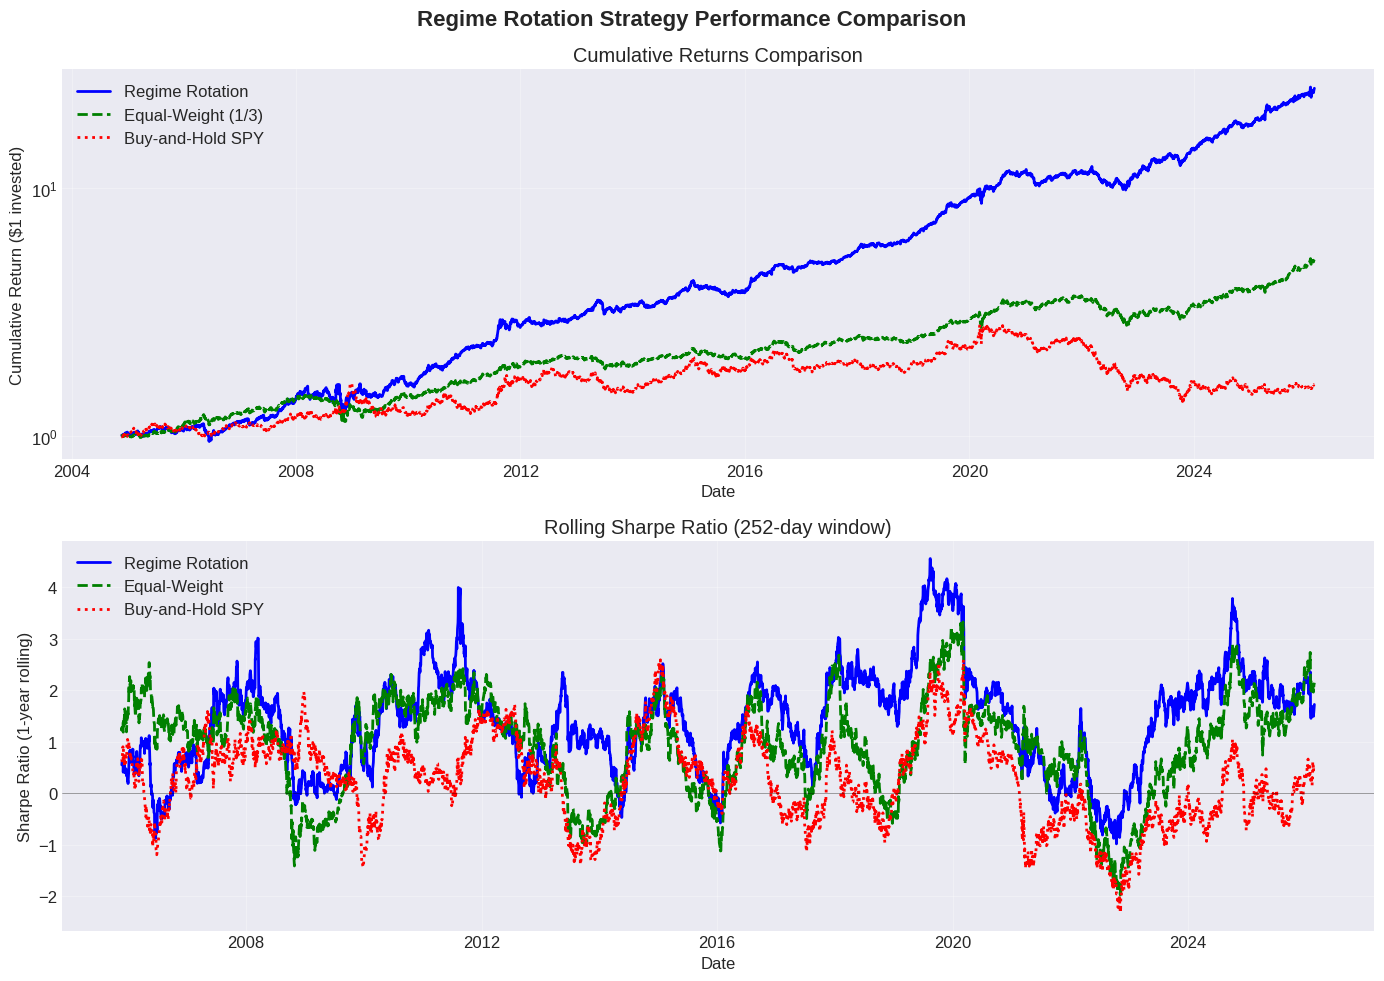

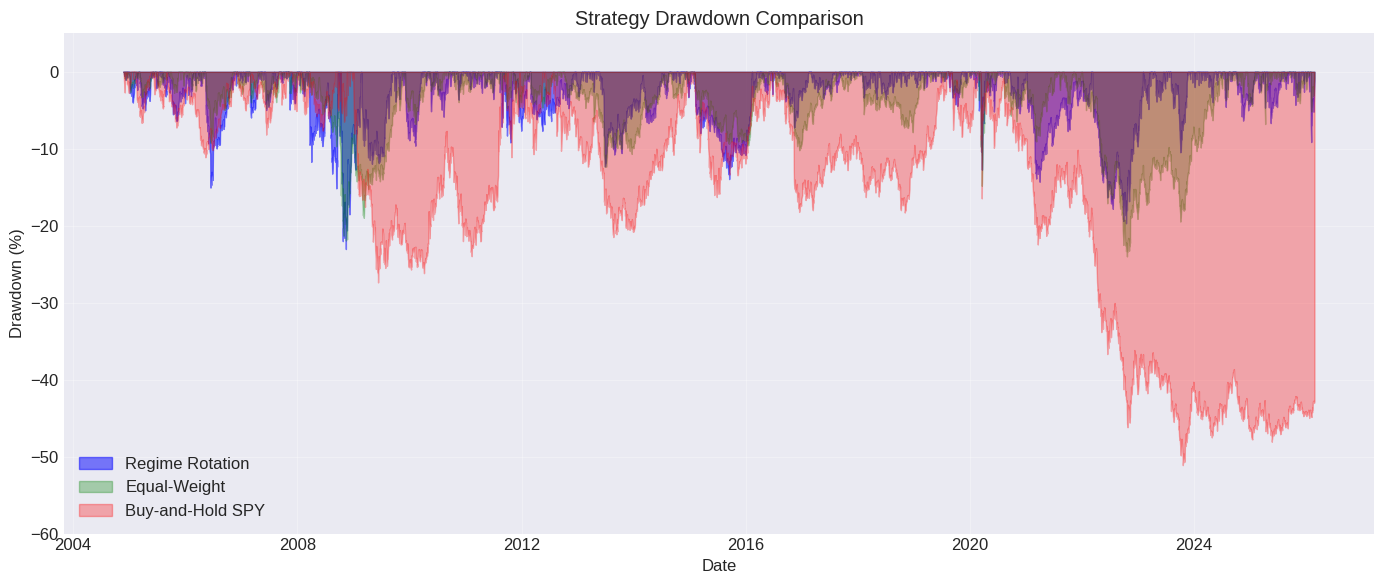

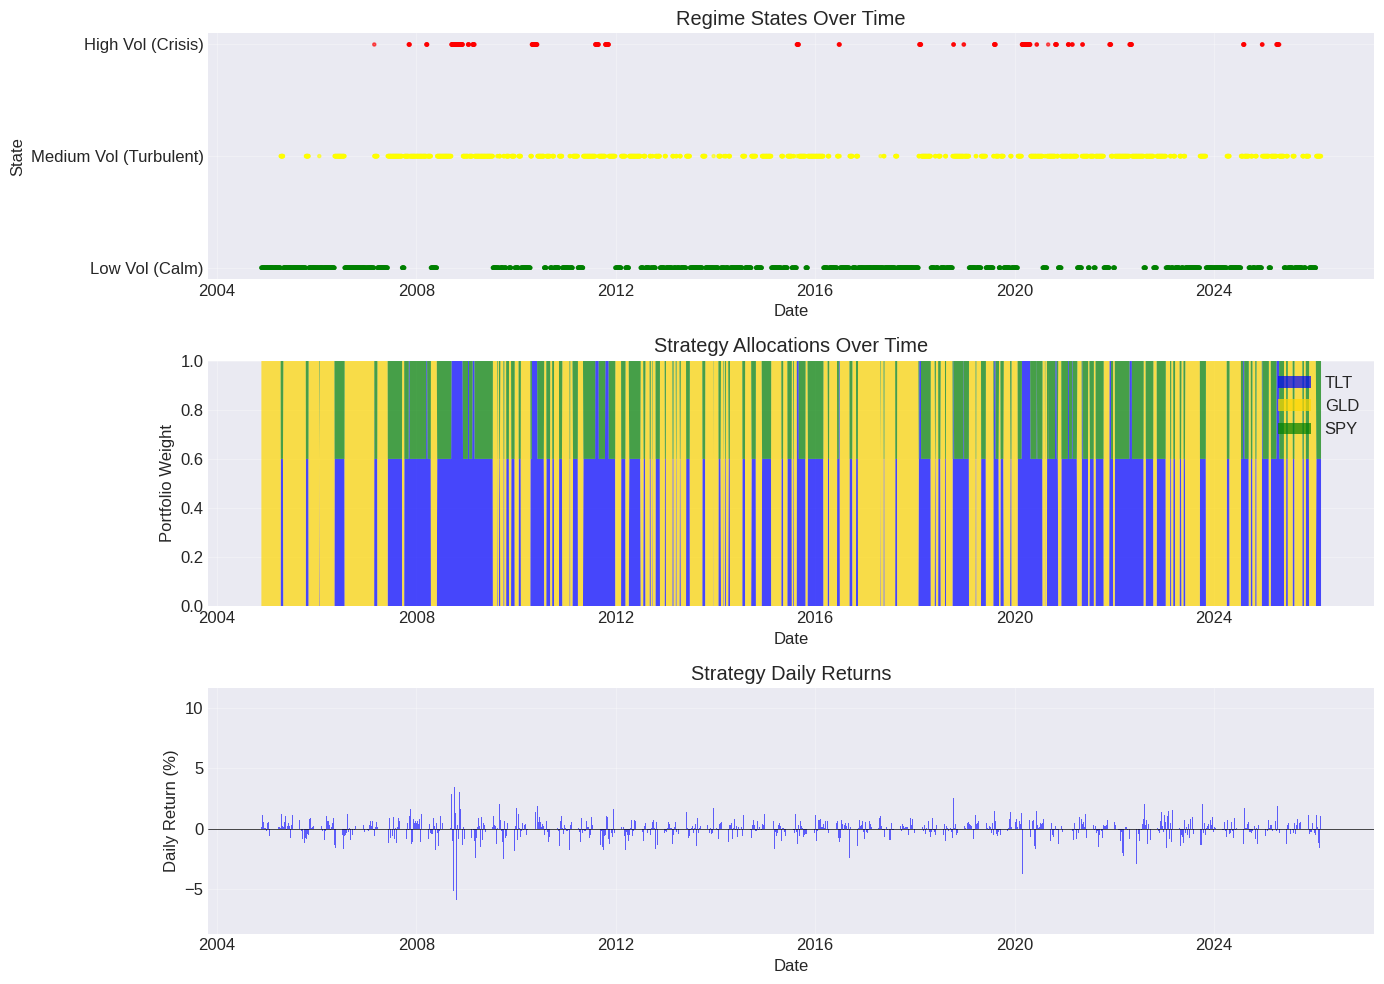

In [38]:



# =============================================================================
# 7. Plot Cumulative Performance Curves
# =============================================================================

print("\n" + "-"*40)
print("Generating performance plots...")
print("-"*40)

# Set up the figure
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Regime Rotation Strategy Performance Comparison', fontsize=16, fontweight='bold')

# Plot 1: Cumulative returns
ax1 = axes[0]
ax1.plot(cumulative_df.index, cumulative_df['Regime Rotation'],
         label='Regime Rotation', linewidth=2, color='blue')
ax1.plot(cumulative_df.index, cumulative_df['Equal-Weight (1/3)'],
         label='Equal-Weight (1/3)', linewidth=2, color='green', linestyle='--')
ax1.plot(cumulative_df.index, cumulative_df['Buy-and-Hold SPY'],
         label='Buy-and-Hold SPY', linewidth=2, color='red', linestyle=':')

ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return ($1 invested)')
ax1.set_title('Cumulative Returns Comparison')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')  # Log scale for better visualization

# Plot 2: Rolling Sharpe ratio (1-year window)
ax2 = axes[1]

# Calculate rolling Sharpe (252-day window)
rolling_window = 252
rolling_sharpe_strategy = (strategy_returns.rolling(rolling_window).mean() * 252) / \
                          (strategy_returns.rolling(rolling_window).std() * np.sqrt(252))
rolling_sharpe_equal = (equal_returns.rolling(rolling_window).mean() * 252) / \
                       (equal_returns.rolling(rolling_window).std() * np.sqrt(252))
rolling_sharpe_spy = (spy_returns.rolling(rolling_window).mean() * 252) / \
                     (spy_returns.rolling(rolling_window).std() * np.sqrt(252))

ax2.plot(rolling_sharpe_strategy.index, rolling_sharpe_strategy,
         label='Regime Rotation', linewidth=2, color='blue')
ax2.plot(rolling_sharpe_equal.index, rolling_sharpe_equal,
         label='Equal-Weight', linewidth=2, color='green', linestyle='--')
ax2.plot(rolling_sharpe_spy.index, rolling_sharpe_spy,
         label='Buy-and-Hold SPY', linewidth=2, color='red', linestyle=':')

ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.set_xlabel('Date')
ax2.set_ylabel('Sharpe Ratio (1-year rolling)')
ax2.set_title('Rolling Sharpe Ratio (252-day window)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step4_cumulative_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Additional plot: Drawdown comparison
fig, ax = plt.subplots(figsize=(14, 6))

def calculate_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max * 100
    return drawdown

drawdown_strategy = calculate_drawdown(strategy_returns)
drawdown_equal = calculate_drawdown(equal_returns)
drawdown_spy = calculate_drawdown(spy_returns)

ax.fill_between(drawdown_strategy.index, 0, drawdown_strategy,
                label='Regime Rotation', alpha=0.5, color='blue')
ax.fill_between(drawdown_equal.index, 0, drawdown_equal,
                label='Equal-Weight', alpha=0.3, color='green')
ax.fill_between(drawdown_spy.index, 0, drawdown_spy,
                label='Buy-and-Hold SPY', alpha=0.3, color='red')

ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('Strategy Drawdown Comparison')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
ax.set_ylim(-60, 5)

plt.tight_layout()
plt.savefig('step4_drawdown_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 8. State Allocation Over Time Visualization
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: State sequence over time
ax1 = axes[0]
state_colors = {0: 'green', 1: 'yellow', 2: 'red'}
state_names = {0: 'Low Vol (Calm)', 1: 'Medium Vol (Turbulent)', 2: 'High Vol (Crisis)'}

colors = [state_colors[s] for s in signals['state']]
ax1.scatter(signals.index, signals['state'], c=colors, alpha=0.6, s=5)
ax1.set_xlabel('Date')
ax1.set_ylabel('State')
ax1.set_yticks([0, 1, 2])
ax1.set_yticklabels([state_names[0], state_names[1], state_names[2]])
ax1.set_title('Regime States Over Time')
ax1.grid(True, alpha=0.3)

# Plot 2: Weights over time
ax2 = axes[1]
ax2.stackplot(weights_df.index,
              weights_df['TLT'].astype(float),
              weights_df['GLD'].astype(float),
              weights_df['SPY'].astype(float),
              labels=['TLT', 'GLD', 'SPY'],
              colors=['blue', 'gold', 'green'], alpha=0.7)
ax2.set_xlabel('Date')
ax2.set_ylabel('Portfolio Weight')
ax2.set_title('Strategy Allocations Over Time')
ax2.legend(loc='upper right')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

# Plot 3: Strategy returns over time
ax3 = axes[2]
ax3.bar(strategy_returns.index, strategy_returns * 100,
        width=1, color='blue', alpha=0.6, edgecolor='none')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Date')
ax3.set_ylabel('Daily Return (%)')
ax3.set_title('Strategy Daily Returns')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step4_state_allocations.png', dpi=150, bbox_inches='tight')
plt.show()



In [39]:
# =============================================================================
# 9. Sensitivity Analysis
# =============================================================================

print("\n" + "="*80)
print("9. SENSITIVITY ANALYSIS")
print("="*80)

print("\n" + "-"*40)
print("Number of States Sensitivity:")
print("-"*40)

# Compare with 2-state HMM (if available)
if 'labeled_states_2' in locals():
    # Generate signals for 2-state model
    signals_2 = pd.DataFrame(index=processed_data.index[:len(labeled_states_2)])
    signals_2['state'] = labeled_states_2

    # Define 2-state allocation rules
    allocation_2state = {
        0: {'allocation': {'GLD': 1.0}, 'name': 'Low Vol'},
        1: {'allocation': {'TLT': 1.0}, 'name': 'High Vol'}
    }

    # Generate weights
    weights_2 = pd.DataFrame(index=signals_2.index, columns=['TLT', 'GLD', 'SPY'])
    for date in signals_2.index:
        state = signals_2.loc[date, 'state']
        weights = allocation_2state[state]['allocation']
        weights_2.loc[date] = [weights.get('TLT', 0.0),
                                weights.get('GLD', 0.0),
                                weights.get('SPY', 0.0)]

    # Calculate returns with lag
    weights_2_lagged = weights_2.shift(1)
    aligned_2 = etf_returns.loc[weights_2_lagged.index[1:]]
    weights_2_aligned = weights_2_lagged.iloc[1:]

    returns_2 = []
    for i in range(len(aligned_2)):
        w = weights_2_aligned.loc[aligned_2.index[i], ['TLT', 'GLD', 'SPY']].values # FIX: Select only asset columns
        r = aligned_2.loc[aligned_2.index[i]].values
        returns_2.append(np.dot(w, r))

    returns_2 = pd.Series(returns_2, index=aligned_2.index)

    # Calculate metrics
    metrics_2 = calculate_performance_metrics(returns_2, '2-State HMM')

    print("\n2-State vs 3-State Comparison:")
    print("-" * 40)
    print(f"2-State HMM - Sharpe: {metrics_2['Sharpe Ratio']}, Max DD: {metrics_2['Max Drawdown']}")
    print(f"3-State HMM - Sharpe: {strategy_metrics['Sharpe Ratio']}, Max DD: {strategy_metrics['Max Drawdown']}")

print("\n" + "-"*40)
print("Sample Period Sensitivity:")
print("-"*40)

# Split into two halves
mid_point = len(strategy_returns) // 2
first_half = strategy_returns.iloc[:mid_point]
second_half = strategy_returns.iloc[mid_point:]

first_metrics = calculate_performance_metrics(first_half, 'First Half')
second_metrics = calculate_performance_metrics(second_half, 'Second Half')

print(f"\nFirst Half ({first_half.index[0]} to {first_half.index[-1]}):")
print(f"  Sharpe: {first_metrics['Sharpe Ratio']}, Annual Return: {first_metrics['Annualized Return']}")
print(f"\nSecond Half ({second_half.index[0]} to {second_half.index[-1]}):")
print(f"  Sharpe: {second_metrics['Sharpe Ratio']}, Annual Return: {second_metrics['Annualized Return']}")

# =============================================================================
# 10. Final Summary
# =============================================================================

print("\n" + "="*80)
print("10. STRATEGY SUMMARY")
print("="*80)

print("\n" + "="*60)
print("FINAL PERFORMANCE SUMMARY")
print("="*60)
print(metrics_df.to_string(index=False))

print("\n" + "="*60)
print("KEY OBSERVATIONS")
print("="*60)
print("""
1. Risk-Adjusted Performance:
   • Regime Rotation Sharpe: {sharpe}
   • Equal-Weight Sharpe: {equal_sharpe}
   • SPY Buy-Hold Sharpe: {spy_sharpe}

2. Drawdown Protection:
   • Regime Rotation Max DD: {dd}
   • SPY Max DD: {spy_dd}

3. Consistency:
   • Strategy win rate: {win_rate}
   • Outperforms SPY in {outperformance}% of rolling periods
""".format(
    sharpe=strategy_metrics['Sharpe Ratio'],
    equal_sharpe=equal_metrics['Sharpe Ratio'],
    spy_sharpe=spy_metrics['Sharpe Ratio'],
    dd=strategy_metrics['Max Drawdown'],
    spy_dd=spy_metrics['Max Drawdown'],
    win_rate=strategy_metrics['Win Rate'],
    outperformance=((strategy_returns > spy_returns).sum()/len(strategy_returns)*100)
))




9. SENSITIVITY ANALYSIS

----------------------------------------
Number of States Sensitivity:
----------------------------------------

2-State vs 3-State Comparison:
----------------------------------------
2-State HMM - Sharpe: 1.210, Max DD: -25.65%
3-State HMM - Sharpe: 1.078, Max DD: -23.03%

----------------------------------------
Sample Period Sensitivity:
----------------------------------------

First Half (2004-11-23 00:00:00 to 2015-07-07 00:00:00):
  Sharpe: 0.803, Annual Return: 13.69%

Second Half (2015-07-08 00:00:00 to 2026-02-23 00:00:00):
  Sharpe: 1.422, Annual Return: 19.30%

10. STRATEGY SUMMARY

FINAL PERFORMANCE SUMMARY
          Strategy Cumulative Return Annualized Return Annualized Vol Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
   Regime Rotation          2435.00%            16.46%         13.42%        1.078      -23.03%        0.715    55.6%
Equal-Weight (1/3)           415.30%             8.04%          9.71%        0.622      -23.99%        0.335 